# Importing libraries

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency, pearsonr
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_percentage_error


import warnings
warnings.filterwarnings('ignore')

# Set consistent plot style
sns.set(style="whitegrid")

# Reading the Dataset

In [50]:
df = pd.read_excel("/content/Sales(data).xlsx")

In [51]:
df.head()

,CustID,AgentBonus,Age,CustTenure,Channel,Occupation,EducationField,Gender,ExistingProdType,Designation,NumberOfPolicy,MaritalStatus,MonthlyIncome,Complaint,ExistingPolicyTenure,SumAssured,Zone,PaymentMethod,LastMonthCalls,CustCareScore
0,7000000,4409,22.0,4.0,Agent,Salaried,Graduate,Female,3,Manager,2.0,Single,20993.0,1,2.0,806761.0,North,Half Yearly,5,2.0
1,7000001,2214,11.0,2.0,Third Party Partner,Salaried,Graduate,Male,4,Manager,4.0,Divorced,20130.0,0,3.0,294502.0,North,Yearly,7,3.0
2,7000002,4273,26.0,4.0,Agent,Free Lancer,Post Graduate,Male,4,Exe,3.0,Unmarried,17090.0,1,2.0,NaN,North,Yearly,0,3.0
3,7000003,1791,11.0,NaN,Third Party Partner,Salaried,Graduate,Fe male,3,Executive,3.0,Divorced,17909.0,1,2.0,268635.0,West,Half Yearly,0,5.0
4,7000004,2955,6.0,NaN,Agent,Small Business,UG,Male,3,Executive,4.0,Divorced,18468.0,0,4.0,366405.0,West,Half Yearly,2,5.0


In [52]:
df.shape

(4520, 20)

# Understanding the Dataset

In [53]:
def column_summary(df):
    summary_data = []

    for col_name in df.columns:
        col_dtype = df[col_name].dtype
        num_of_nulls = df[col_name].isnull().sum()
        num_of_non_nulls = df[col_name].notnull().sum()
        num_of_distinct_values = df[col_name].nunique()

        if num_of_distinct_values <= 10:
            distinct_values_counts = df[col_name].value_counts().to_dict()
        else:
            top_10_values_counts = df[col_name].value_counts().head(10).to_dict()
            distinct_values_counts = {k: v for k, v in sorted(top_10_values_counts.items(), key=lambda item: item[1], reverse=True)}

        summary_data.append({
            'col_name': col_name,
            'col_dtype': col_dtype,
            'num_of_nulls': num_of_nulls,
            'num_of_non_nulls': num_of_non_nulls,
            'num_of_distinct_values': num_of_distinct_values,
            'distinct_values_counts': distinct_values_counts
        })

    summary_df = pd.DataFrame(summary_data)
    return summary_df



In [54]:
# Example usage:
# Assuming df is your DataFrame
summary_df = column_summary(df)
display(summary_df)

,col_name,col_dtype,num_of_nulls,num_of_non_nulls,num_of_distinct_values,distinct_values_counts
0,CustID,int64,0,4520,4520,"{7004519: 1, 7000000: 1, 7000001: 1, 7000002: ..."
1,AgentBonus,int64,0,4520,2909,"{2581: 8, 2952: 7, 3642: 7, 4135: 7, 5146: 6, ..."
2,Age,float64,269,4251,53,"{5.0: 239, 8.0: 222, 4.0: 220, 10.0: 207, 9.0:..."
3,CustTenure,float64,226,4294,54,"{4.0: 247, 5.0: 225, 10.0: 213, 3.0: 206, 13.0..."
4,Channel,object,0,4520,3,"{'Agent': 3194, 'Third Party Partner': 858, 'O..."
5,Occupation,object,0,4520,5,"{'Salaried': 2192, 'Small Business': 1918, 'La..."
6,EducationField,object,0,4520,7,"{'Graduate': 1870, 'Under Graduate': 1190, 'Di..."
7,Gender,object,0,4520,3,"{'Male': 2688, 'Female': 1507, 'Fe male': 325}"
8,ExistingProdType,int64,0,4520,6,"{4: 1916, 3: 1369, 5: 708, 2: 221, 1: 183, 6: ..."
9,Designation,object,0,4520,6,"{'Manager': 1620, 'Executive': 1535, 'Senior M..."


In [55]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4520 entries, 0 to 4519
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   CustID                4520 non-null   int64  
 1   AgentBonus            4520 non-null   int64  
 2   Age                   4251 non-null   float64
 3   CustTenure            4294 non-null   float64
 4   Channel               4520 non-null   object 
 5   Occupation            4520 non-null   object 
 6   EducationField        4520 non-null   object 
 7   Gender                4520 non-null   object 
 8   ExistingProdType      4520 non-null   int64  
 9   Designation           4520 non-null   object 
 10  NumberOfPolicy        4475 non-null   float64
 11  MaritalStatus         4520 non-null   object 
 12  MonthlyIncome         4284 non-null   float64
 13  Complaint             4520 non-null   int64  
 14  ExistingPolicyTenure  4336 non-null   float64
 15  SumAssured           

In [56]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
CustID,4520.0,NaN,NaN,NaN,7002259.5,1304.955938,7000000.0,7001129.75,7002259.5,7003389.25,7004519.0
AgentBonus,4520.0,NaN,NaN,NaN,4077.838274,1403.321711,1605.0,3027.75,3911.5,4867.25,9608.0
Age,4251.0,NaN,NaN,NaN,14.494707,9.037629,2.0,7.0,13.0,20.0,58.0
CustTenure,4294.0,NaN,NaN,NaN,14.469027,8.963671,2.0,7.0,13.0,20.0,57.0
Channel,4520,3,Agent,3194,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Occupation,4520,5,Salaried,2192,NaN,NaN,NaN,NaN,NaN,NaN,NaN
EducationField,4520,7,Graduate,1870,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Gender,4520,3,Male,2688,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ExistingProdType,4520.0,NaN,NaN,NaN,3.688938,1.015769,1.0,3.0,4.0,4.0,6.0
Designation,4520,6,Manager,1620,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Dropping the unnecessary columns and correcting the values


In [57]:
columns_to_drop = ['CustID']
df = df.drop(columns=columns_to_drop)


In [58]:
df['Occupation'] = df['Occupation'].replace('Laarge Business', 'Large Business')

In [59]:
df['EducationField'] = df['EducationField'].replace('UG', 'Under Graduate')

In [60]:
df['MaritalStatus'].value_counts()

,count
MaritalStatus,
Married,2268
Single,1254
Divorced,804
Unmarried,194


In [61]:
df['Gender'] = df['Gender'].replace('Fe male', 'Female')

In [62]:
df['Designation'] = df['Designation'].replace('Exe', 'Executive')

In [63]:
df['MaritalStatus'] = df['MaritalStatus'].replace('Unmarried', 'Single')

In [64]:
df['MaritalStatus'].value_counts()

,count
MaritalStatus,
Married,2268
Single,1448
Divorced,804


# Handling Null Values

In [65]:
df.dropna(inplace=True)

In [66]:
df.isnull().sum().sum()

np.int64(0)

In [67]:
summary_df = column_summary(df)
display(summary_df)

,col_name,col_dtype,num_of_nulls,num_of_non_nulls,num_of_distinct_values,distinct_values_counts
0,AgentBonus,int64,0,3447,2366,"{2581: 7, 4135: 6, 5146: 6, 5267: 5, 3379: 5, ..."
1,Age,float64,0,3447,50,"{5.0: 206, 4.0: 181, 8.0: 179, 10.0: 176, 9.0:..."
2,CustTenure,float64,0,3447,52,"{5.0: 197, 4.0: 192, 10.0: 183, 13.0: 162, 3.0..."
3,Channel,object,0,3447,3,"{'Agent': 2413, 'Third Party Partner': 655, 'O..."
4,Occupation,object,0,3447,4,"{'Salaried': 1641, 'Small Business': 1498, 'La..."
5,EducationField,object,0,3447,6,"{'Graduate': 1391, 'Under Graduate': 1075, 'Di..."
6,Gender,object,0,3447,2,"{'Male': 2049, 'Female': 1398}"
7,ExistingProdType,int64,0,3447,6,"{4: 1590, 3: 842, 5: 607, 2: 191, 6: 115, 1: 102}"
8,Designation,object,0,3447,5,"{'Manager': 1588, 'Executive': 1045, 'Senior M..."
9,NumberOfPolicy,float64,0,3447,6,"{4.0: 864, 3.0: 666, 5.0: 659, 2.0: 579, 6.0: ..."


In [68]:
df.duplicated().sum()

np.int64(0)

**No duplicate values**

# EDA

## Univariate Analysis

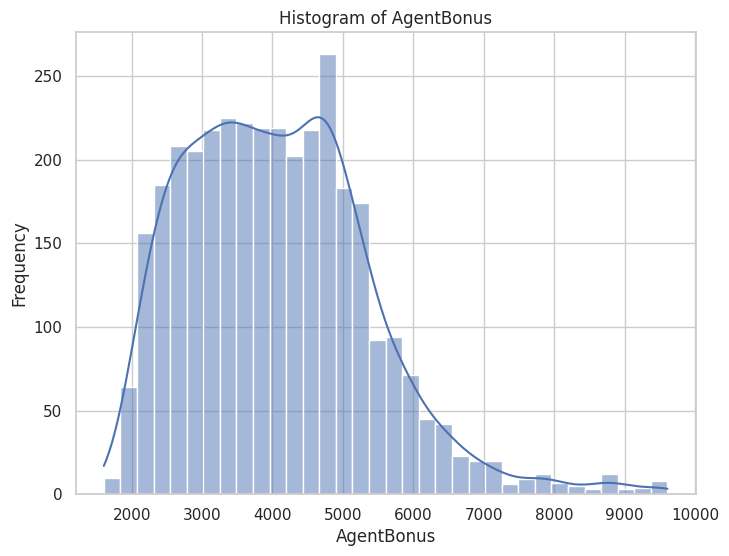

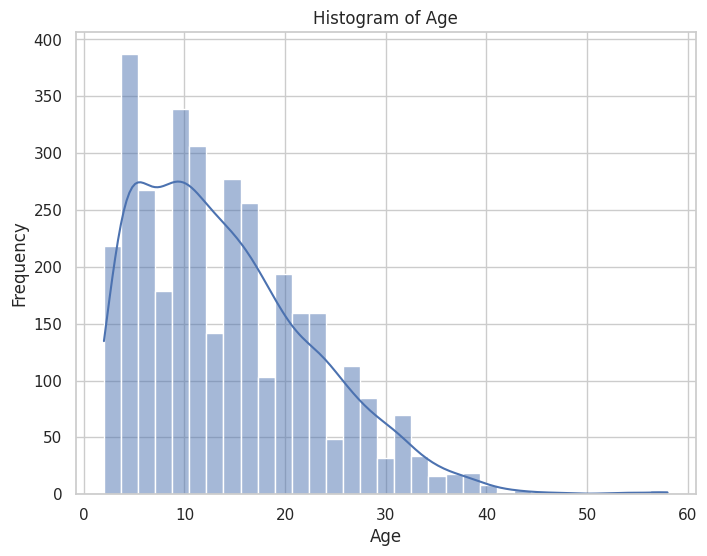

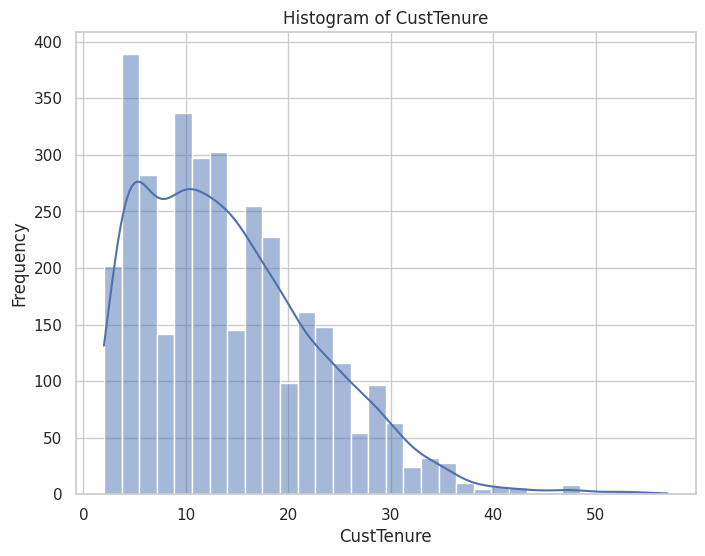

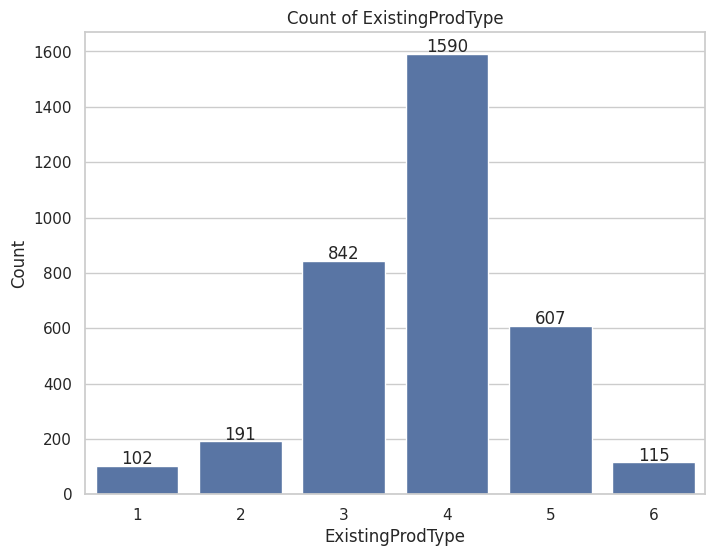

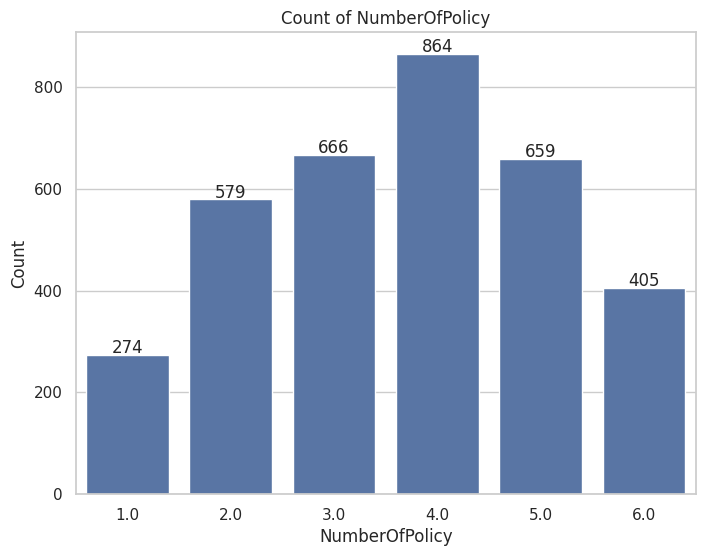

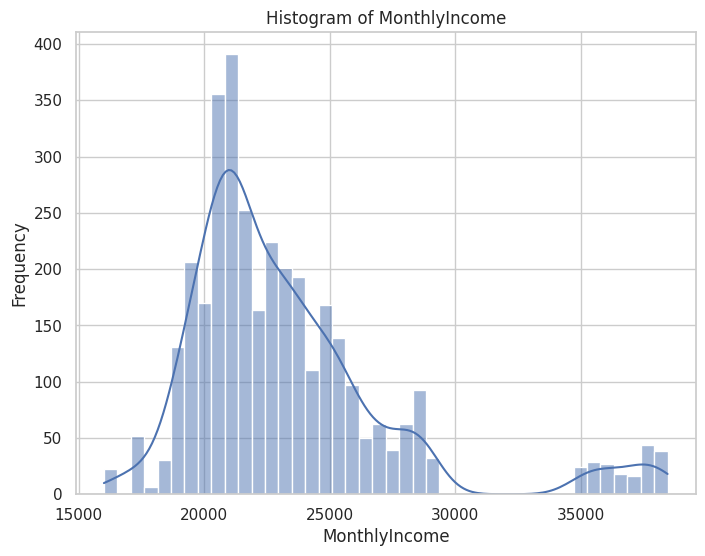

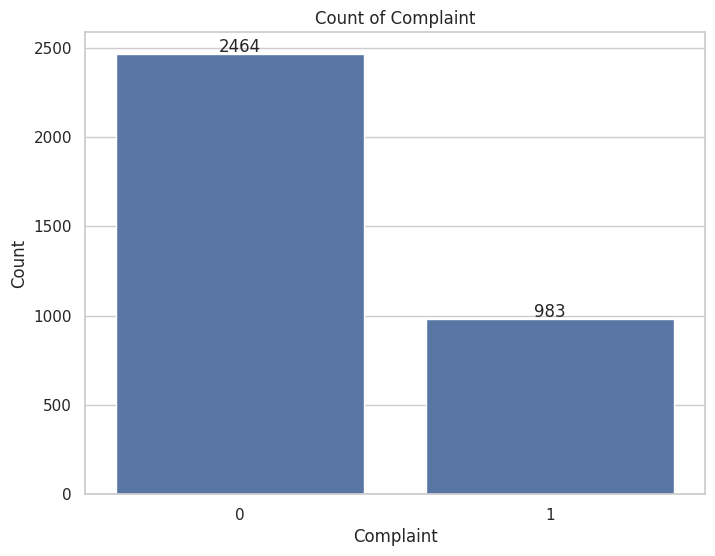

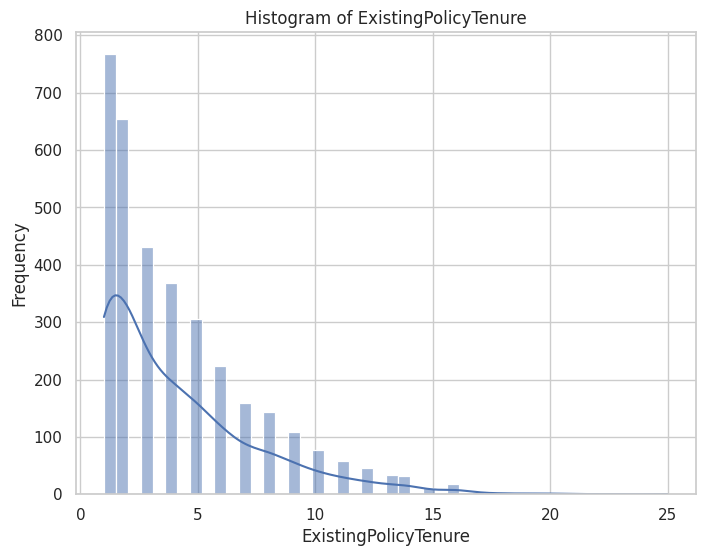

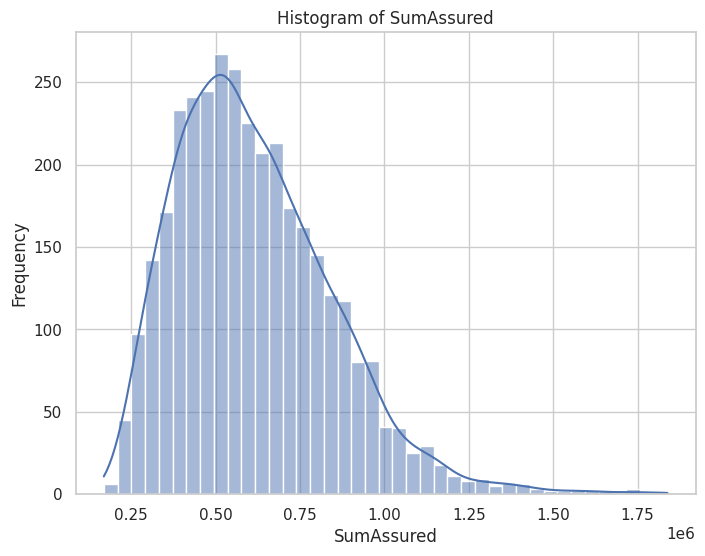

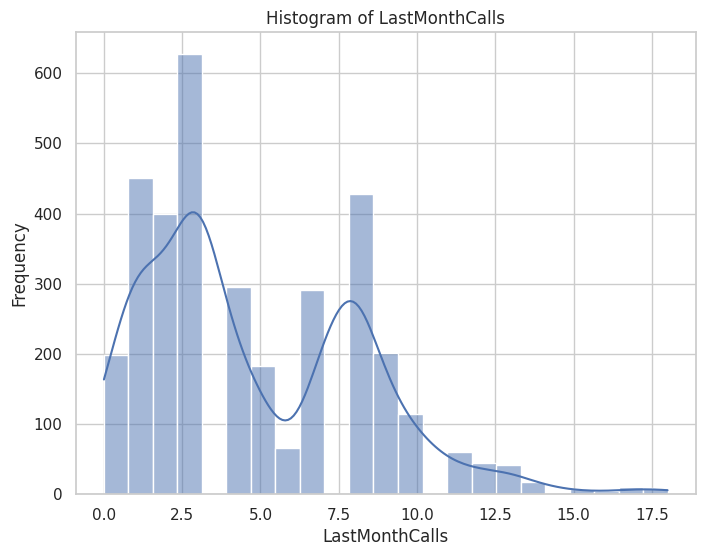

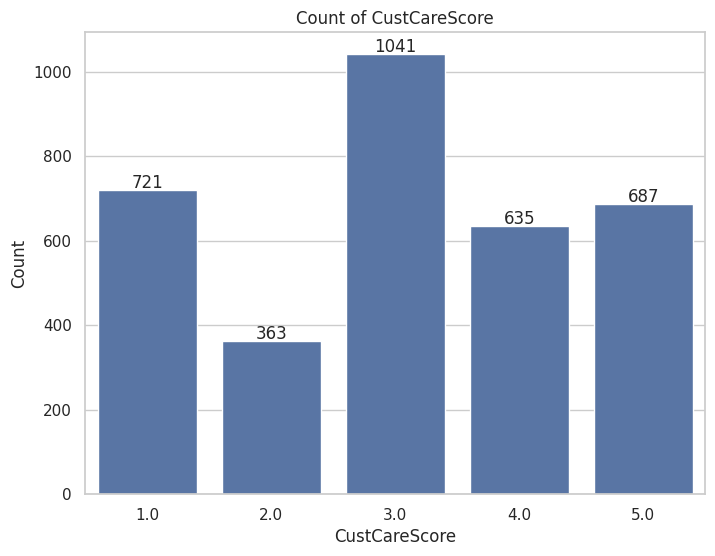

In [ ]:
# Identify numerical columns
numerical_columns = df.select_dtypes(include=[np.number]).columns

# Perform univariate analysis on numerical columns
for column in numerical_columns:
    # For continuous variables
    if len(df[column].unique()) > 10:  # Assuming if unique values > 10, consider it continuous
        plt.figure(figsize=(8, 6))
        sns.histplot(df[column], kde=True)
        plt.title(f'Histogram of {column}')
        plt.xlabel(column)
        plt.ylabel('Frequency')
        plt.show()
    else:  # For discrete or ordinal variables
        plt.figure(figsize=(8, 6))
        ax = sns.countplot(x=column, data=df)
        plt.title(f'Count of {column}')
        plt.xlabel(column)
        plt.ylabel('Count')

        # Annotate each bar with its count
        for p in ax.patches:
            ax.annotate(format(p.get_height(), '.0f'),
                        (p.get_x() + p.get_width() / 2., p.get_height()),
                        ha = 'center', va = 'center',
                        xytext = (0, 5),
                        textcoords = 'offset points')
        plt.show()

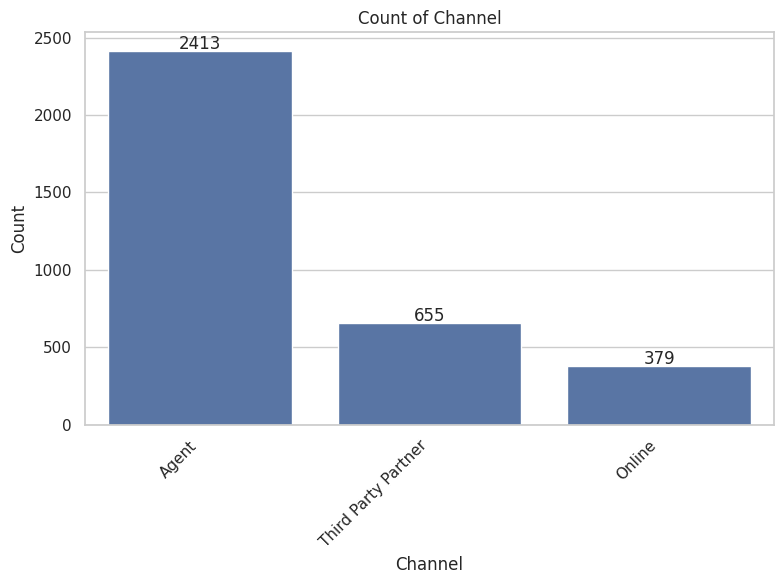

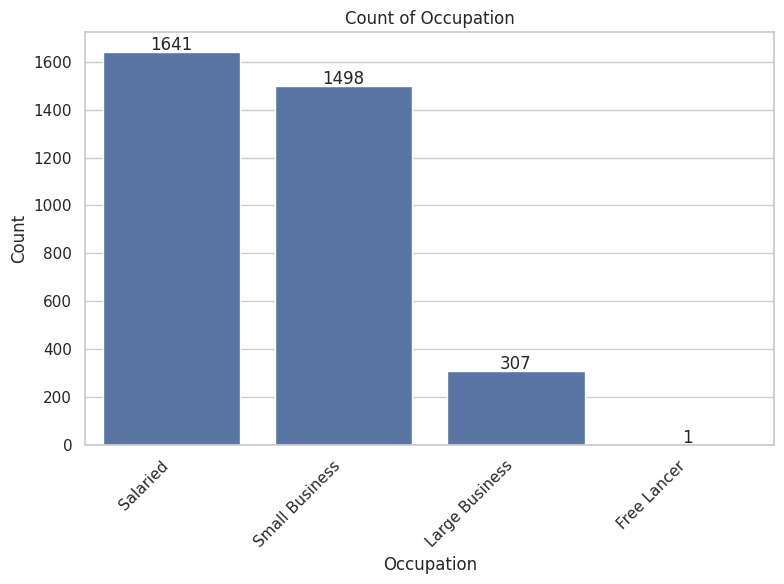

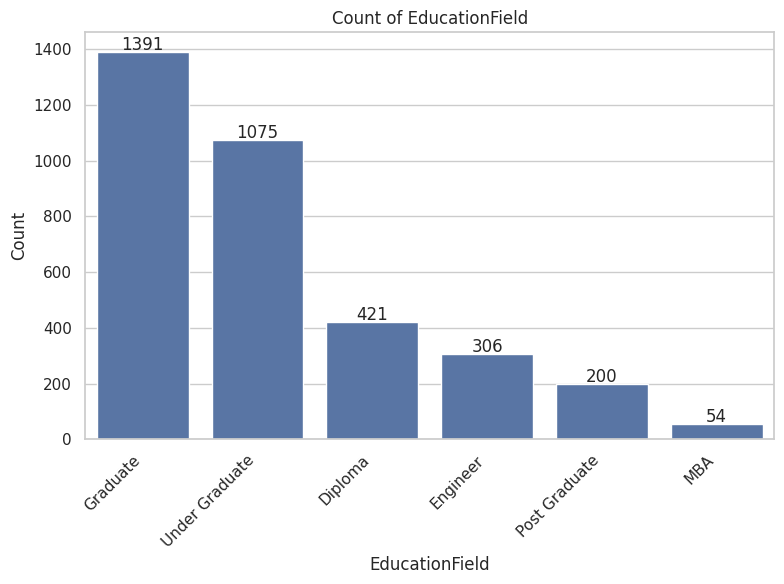

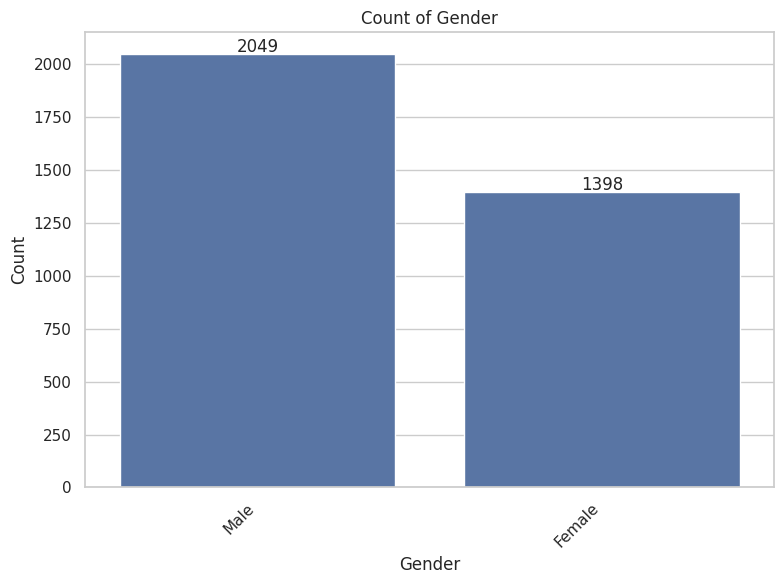

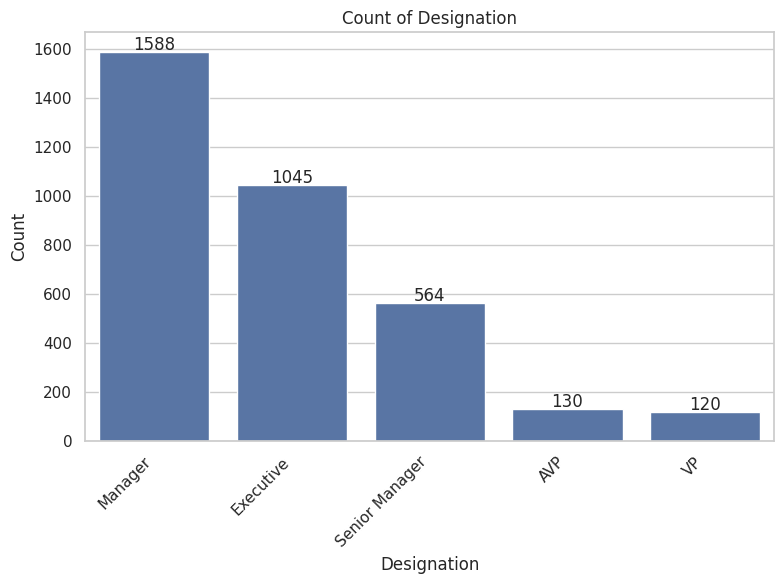

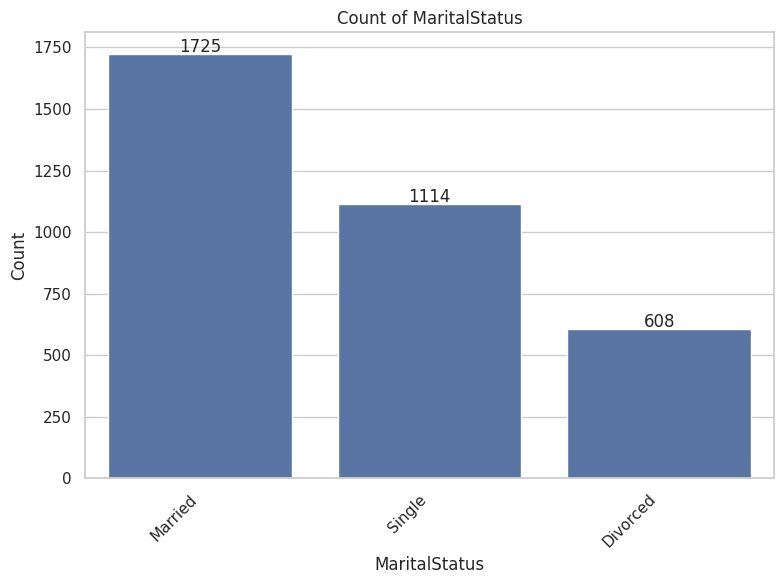

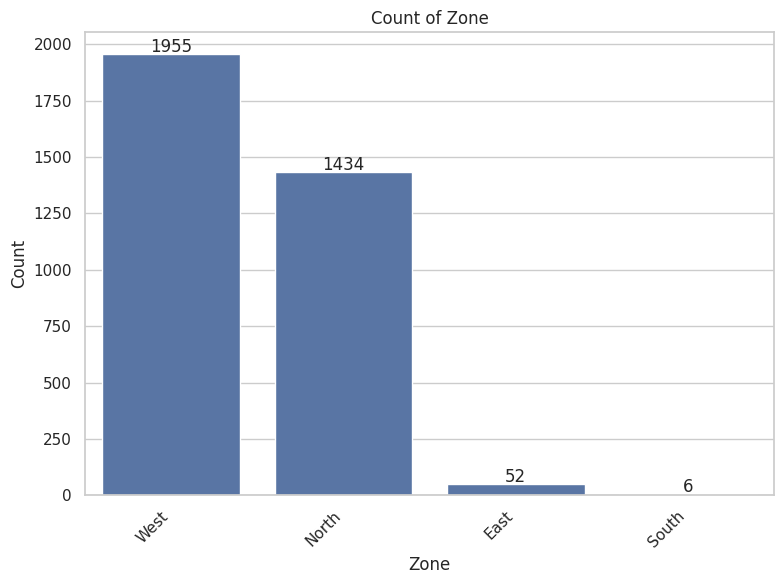

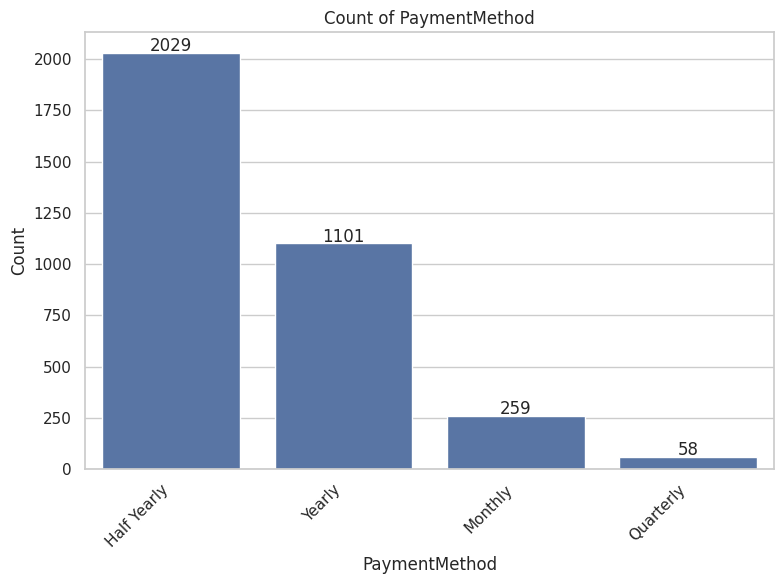

In [ ]:
# Select categorical columns (object, category, bool)
categorical_columns = df.select_dtypes(include=['object', 'category', 'bool']).columns

# Perform univariate analysis on categorical columns
for column in categorical_columns:
    plt.figure(figsize=(8, 6))
    ax = sns.countplot(x=column, data=df, order=df[column].value_counts().index)
    plt.title(f'Count of {column}')
    plt.xlabel(column)
    plt.ylabel('Count')

    # Annotate each bar with its count
    for p in ax.patches:
        ax.annotate(format(p.get_height(), '.0f'),
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center',
                    xytext=(0, 5),
                    textcoords='offset points')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()


## Bivariate Analysis

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3447 entries, 0 to 4519
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   AgentBonus            3447 non-null   int64  
 1   Age                   3447 non-null   float64
 2   CustTenure            3447 non-null   float64
 3   Channel               3447 non-null   object 
 4   Occupation            3447 non-null   object 
 5   EducationField        3447 non-null   object 
 6   Gender                3447 non-null   object 
 7   ExistingProdType      3447 non-null   int64  
 8   Designation           3447 non-null   object 
 9   NumberOfPolicy        3447 non-null   float64
 10  MaritalStatus         3447 non-null   object 
 11  MonthlyIncome         3447 non-null   float64
 12  Complaint             3447 non-null   int64  
 13  ExistingPolicyTenure  3447 non-null   float64
 14  SumAssured            3447 non-null   float64
 15  Zone                  3447

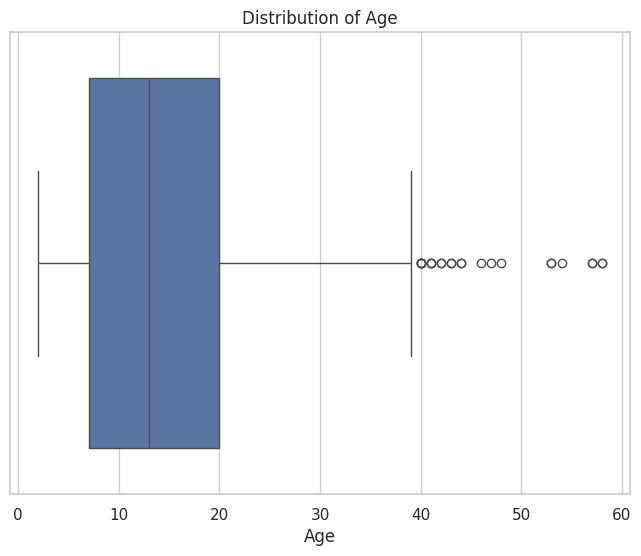

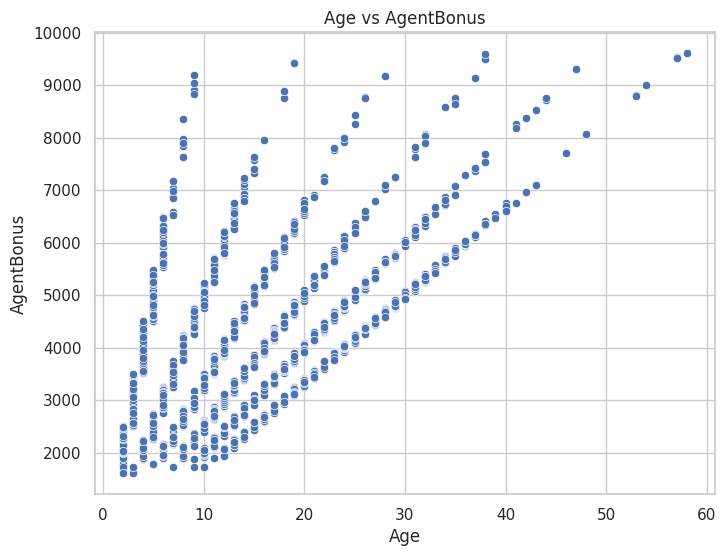

Correlation between Age and AgentBonus: 0.555



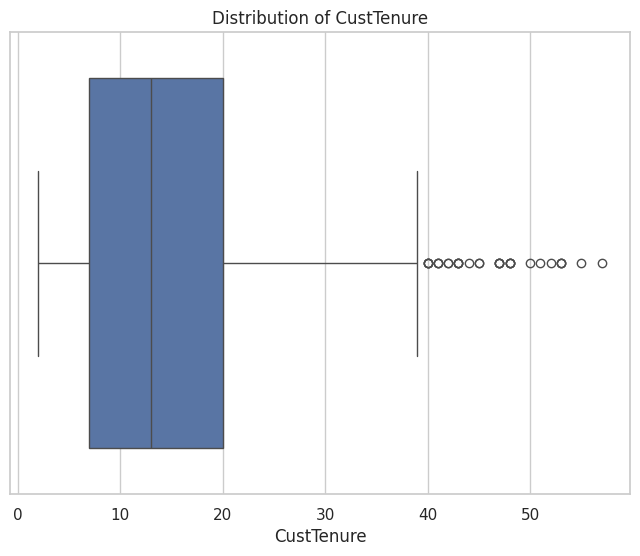

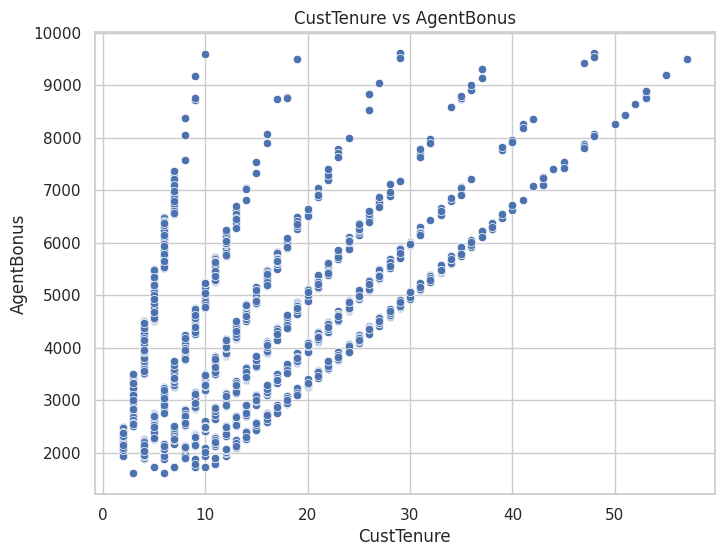

Correlation between CustTenure and AgentBonus: 0.542



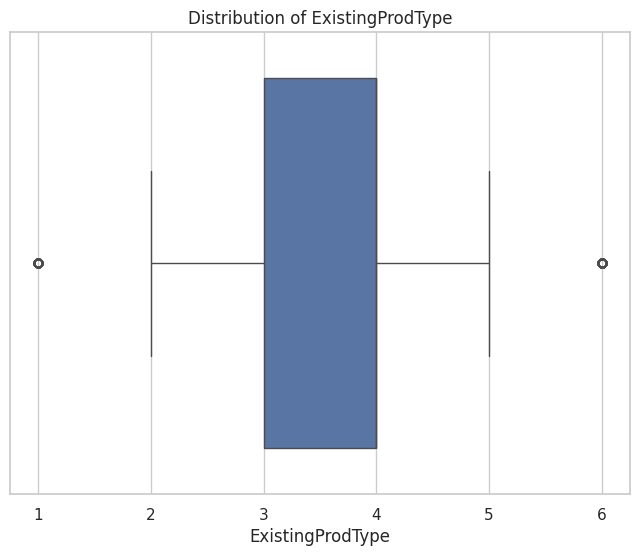

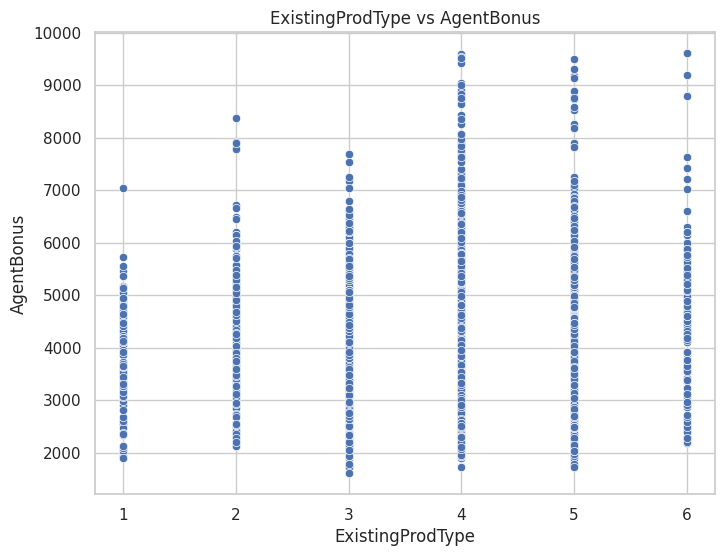

Correlation between ExistingProdType and AgentBonus: 0.101



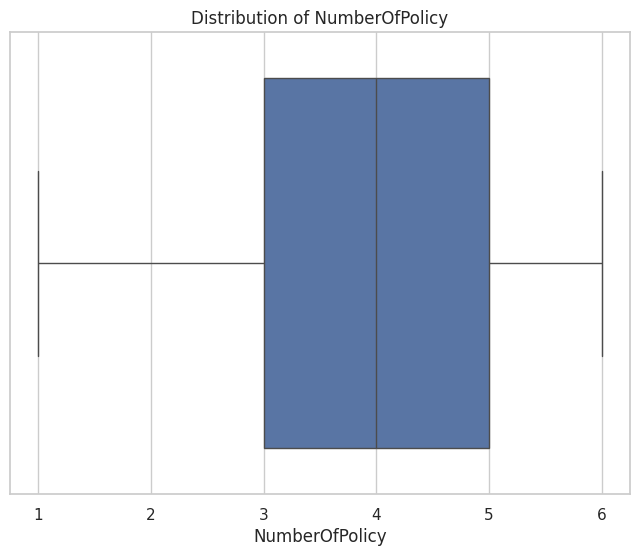

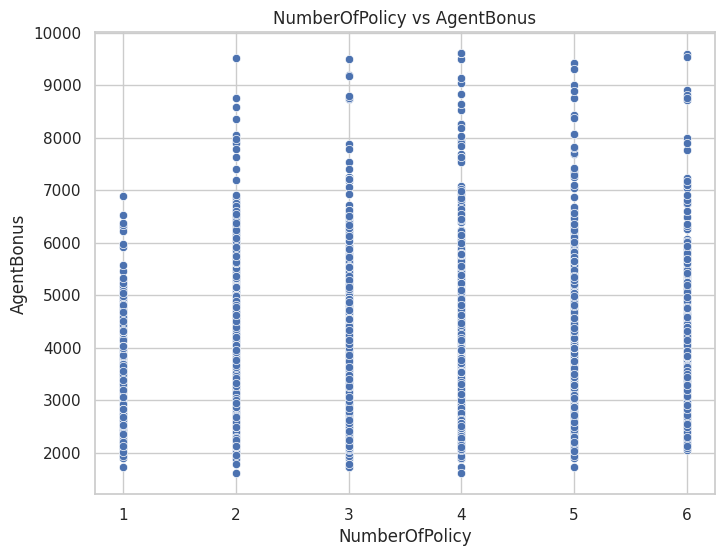

Correlation between NumberOfPolicy and AgentBonus: 0.059



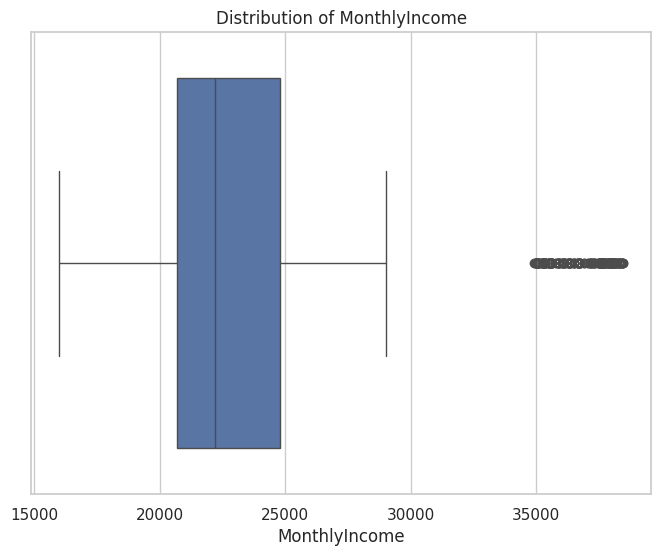

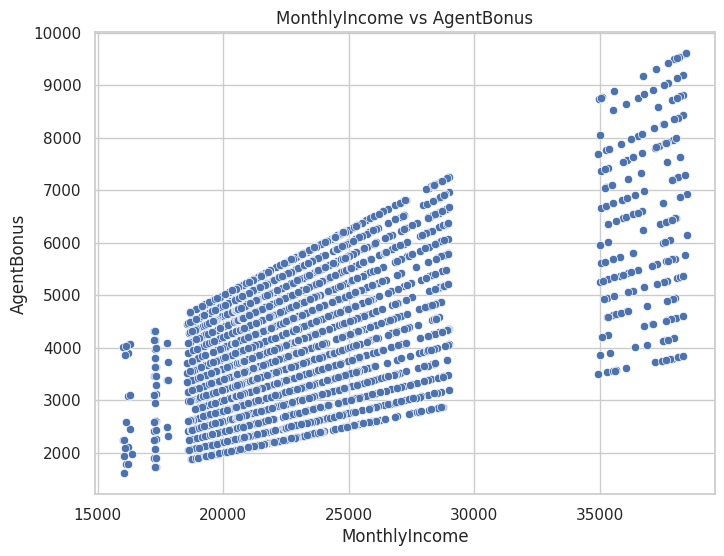

Correlation between MonthlyIncome and AgentBonus: 0.551



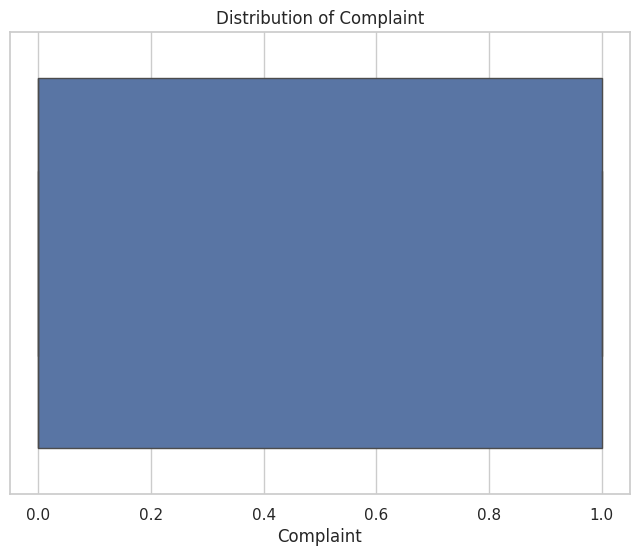

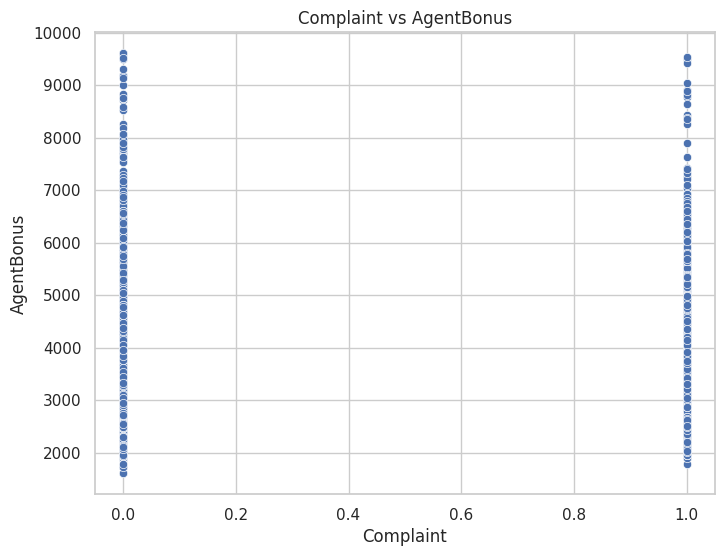

Correlation between Complaint and AgentBonus: 0.004



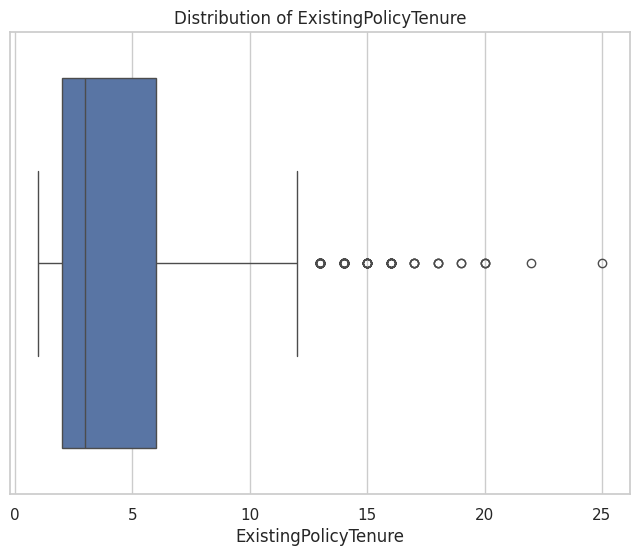

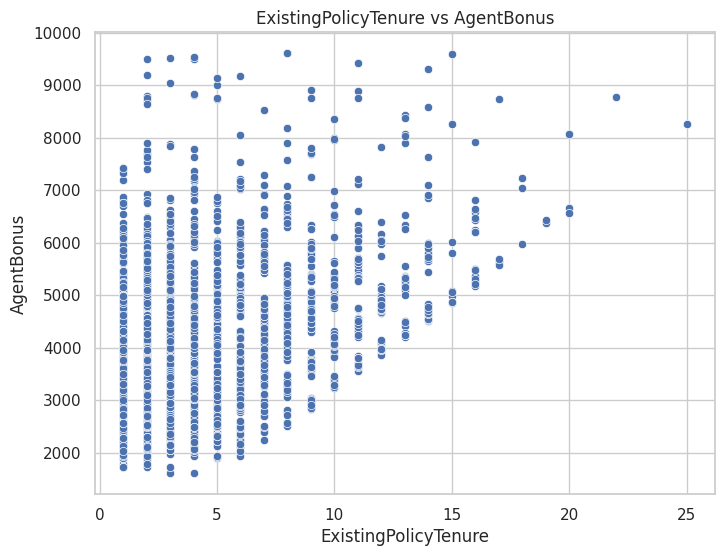

Correlation between ExistingPolicyTenure and AgentBonus: 0.376



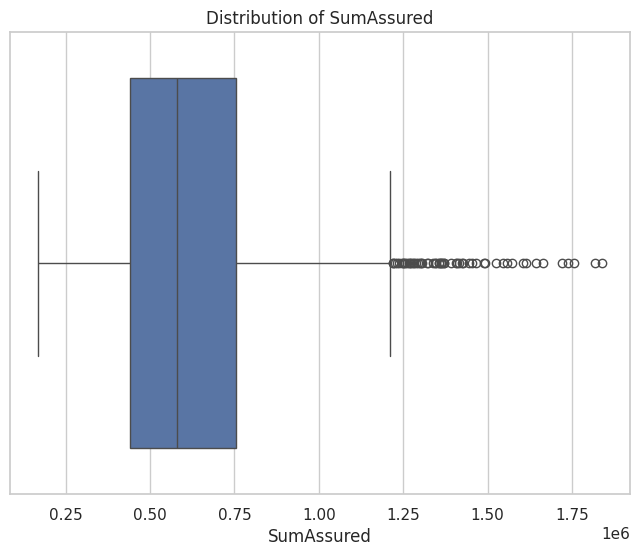

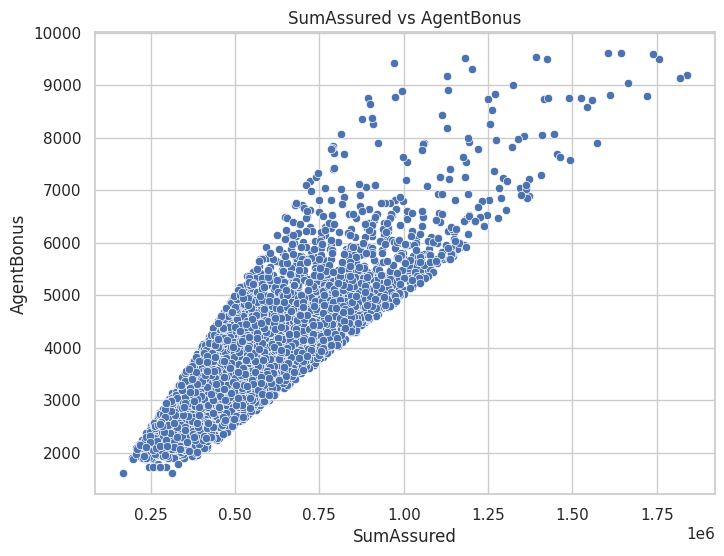

Correlation between SumAssured and AgentBonus: 0.841



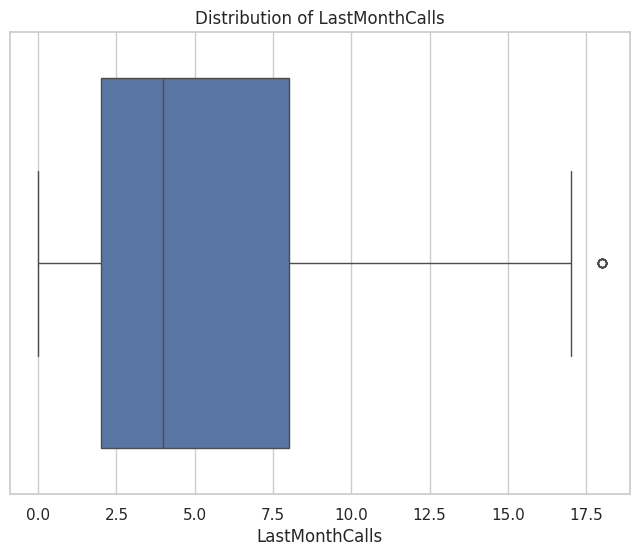

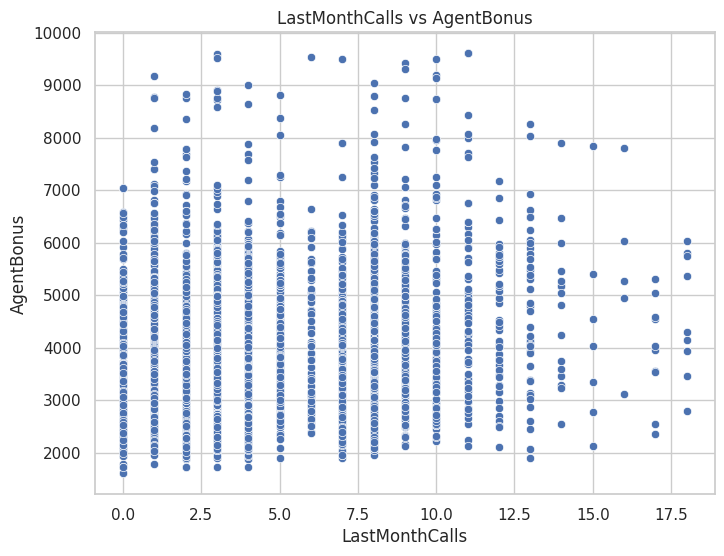

Correlation between LastMonthCalls and AgentBonus: 0.138



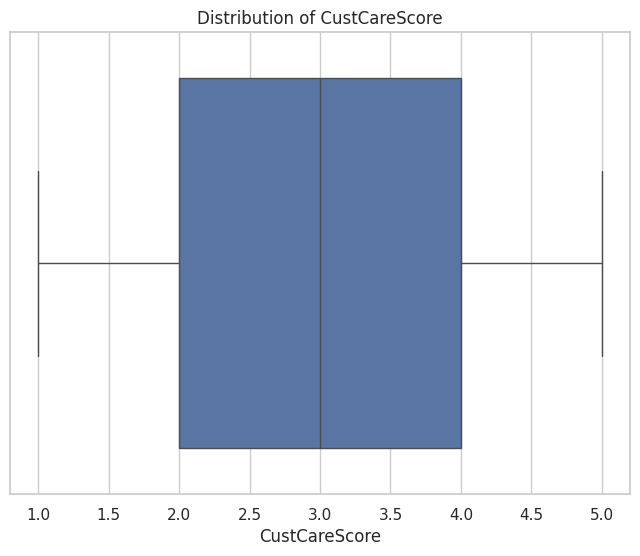

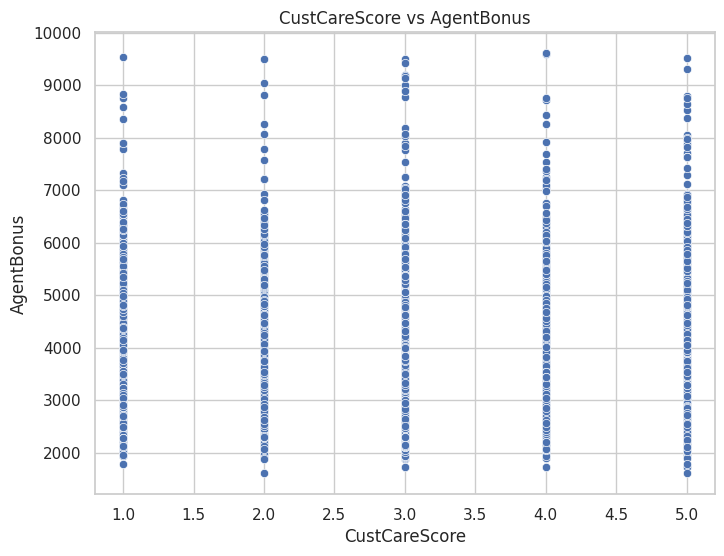

Correlation between CustCareScore and AgentBonus: 0.019



In [ ]:
numerical_cols = df.select_dtypes(include=[np.number]).columns.drop('AgentBonus')

# Boxplots and correlation values
for col in numerical_cols:
    plt.figure(figsize=(8, 6))
    sns.boxplot(x=df[col])
    plt.title(f'Distribution of {col}')
    plt.show()

    plt.figure(figsize=(8, 6))
    sns.scatterplot(x=col, y='AgentBonus', data=df)
    plt.title(f'{col} vs AgentBonus')
    plt.show()

    corr, _ = pearsonr(df[col], df['AgentBonus'])
    print(f'Correlation between {col} and AgentBonus: {corr:.3f}\n')


📊 Channel vs AgentBonus


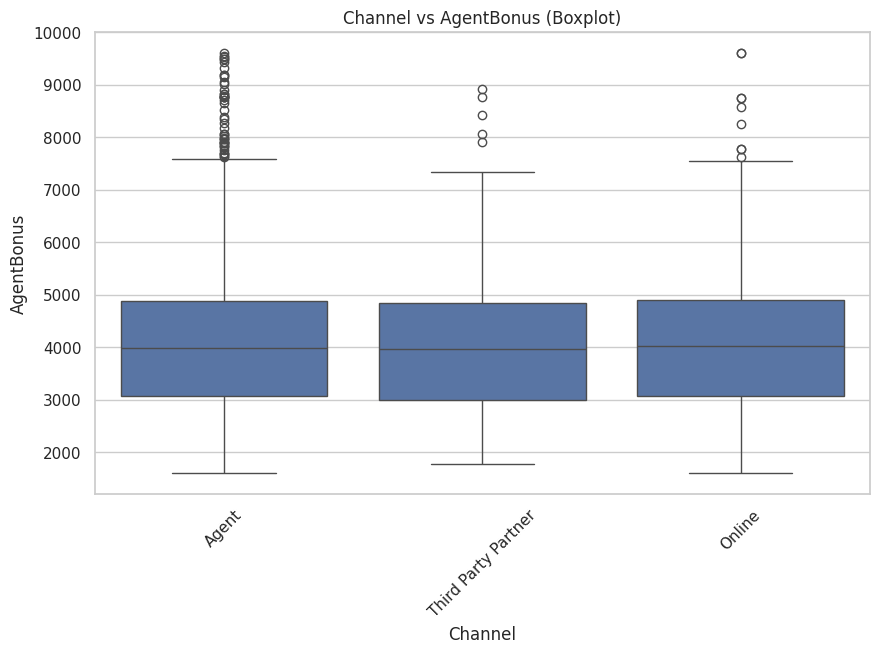

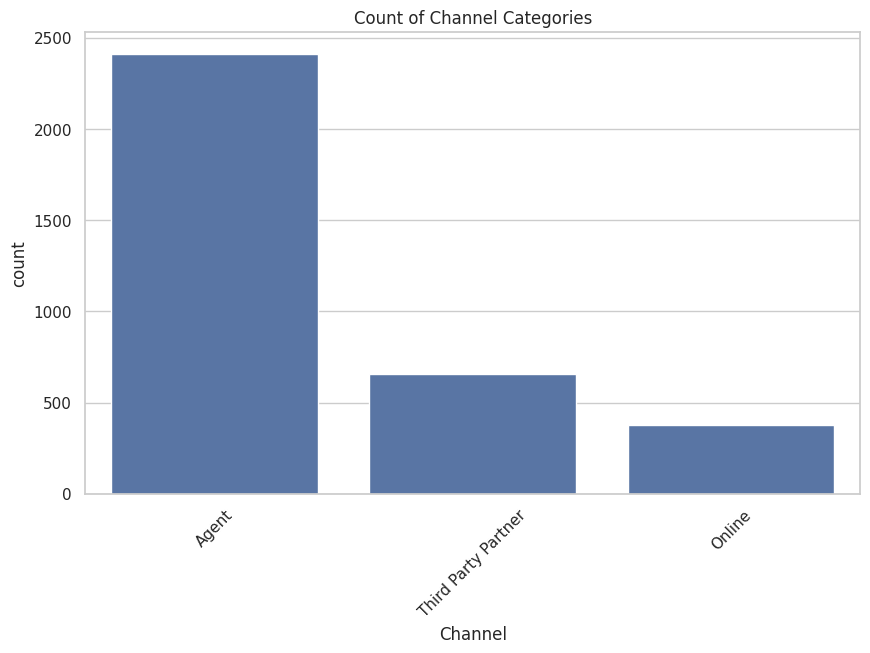

📊 Occupation vs AgentBonus


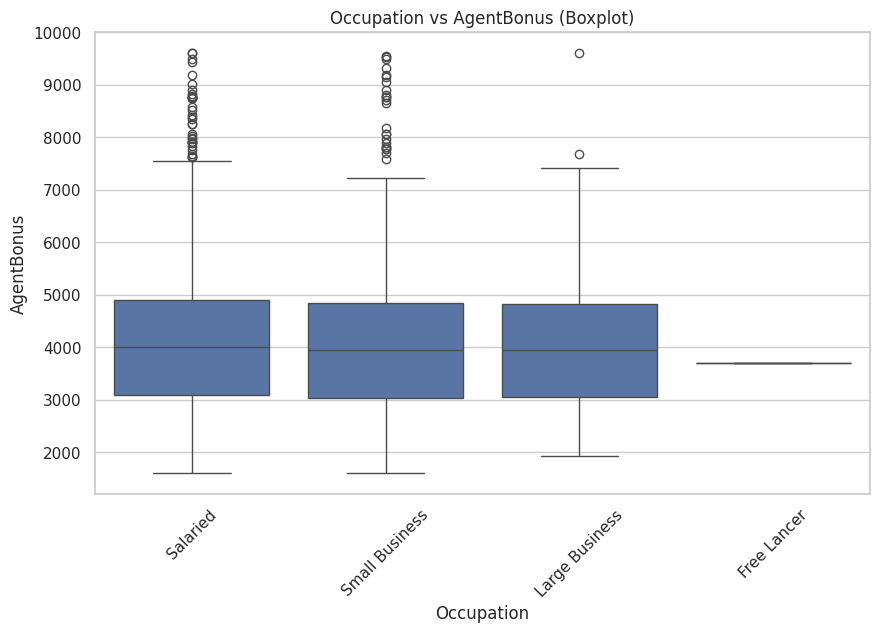

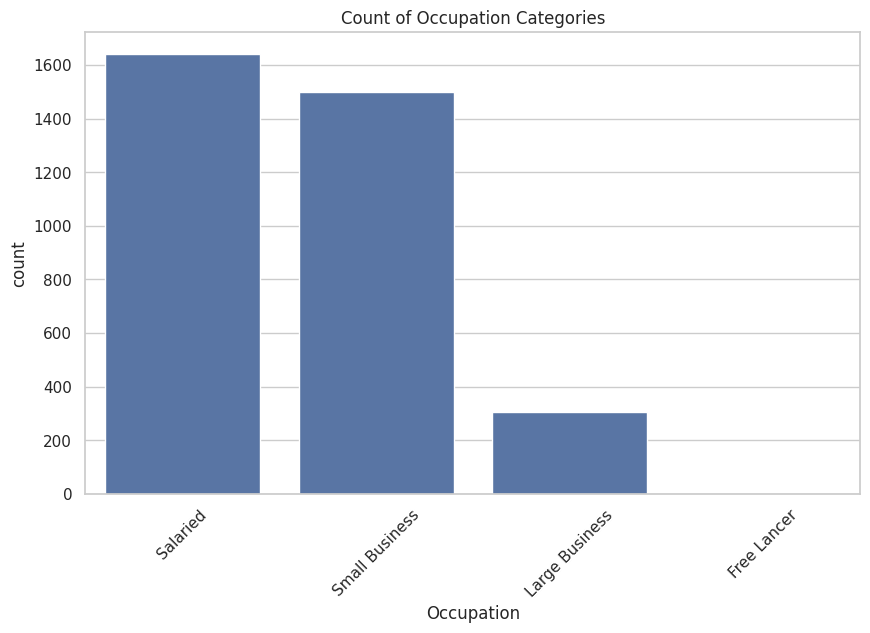

📊 EducationField vs AgentBonus


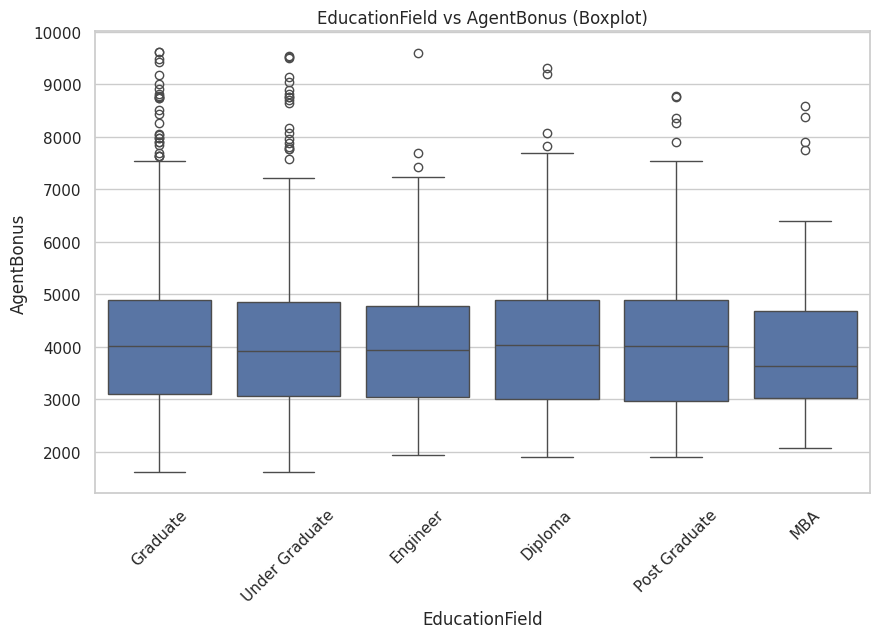

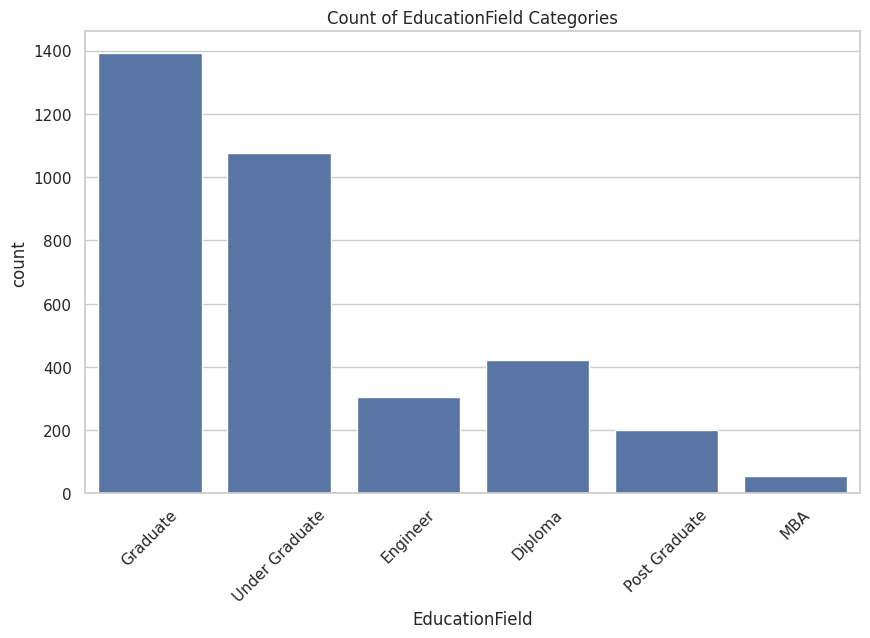

📊 Gender vs AgentBonus


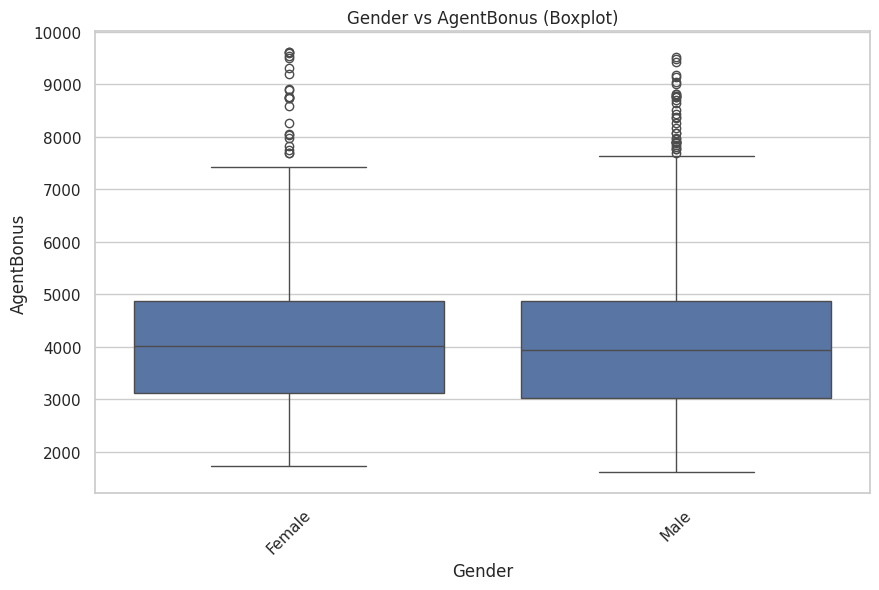

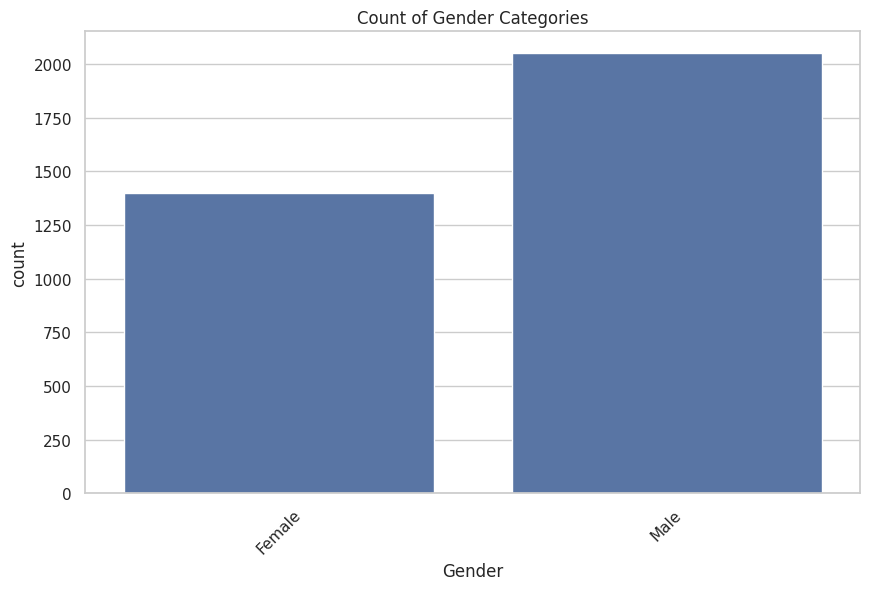

📊 Designation vs AgentBonus


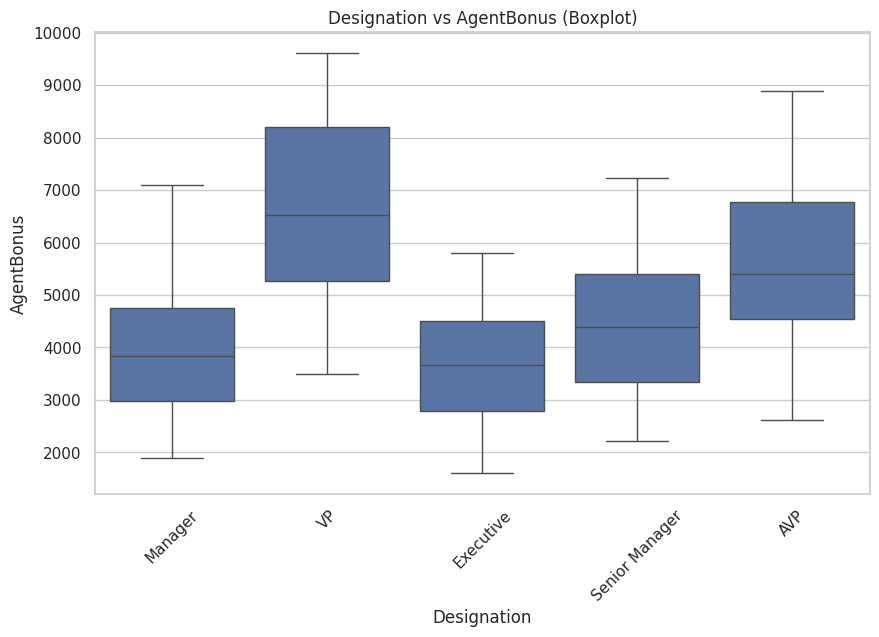

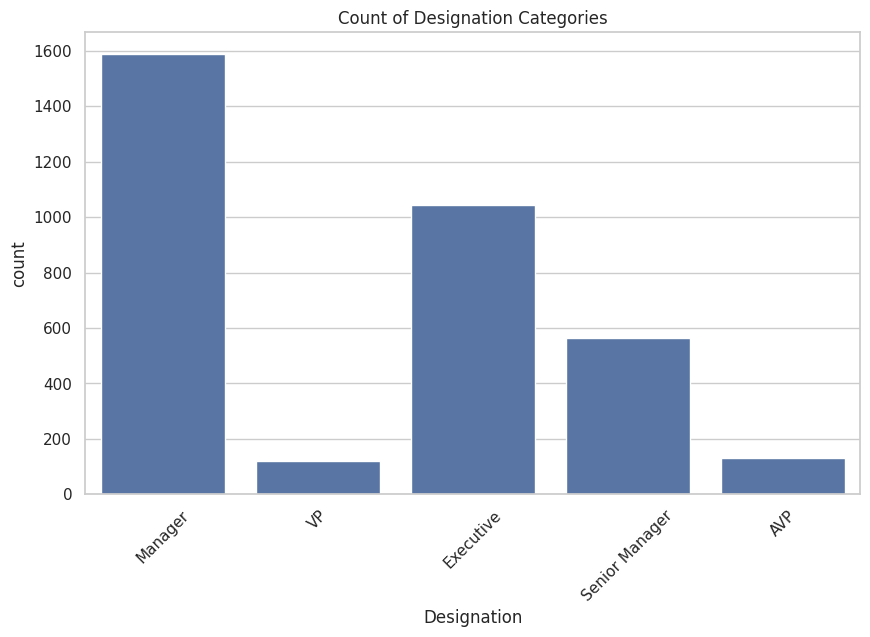

📊 MaritalStatus vs AgentBonus


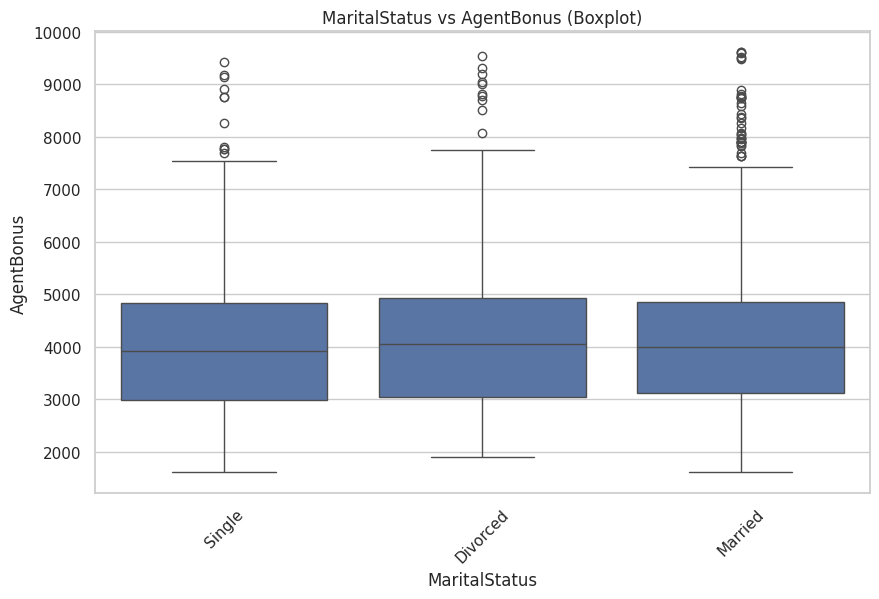

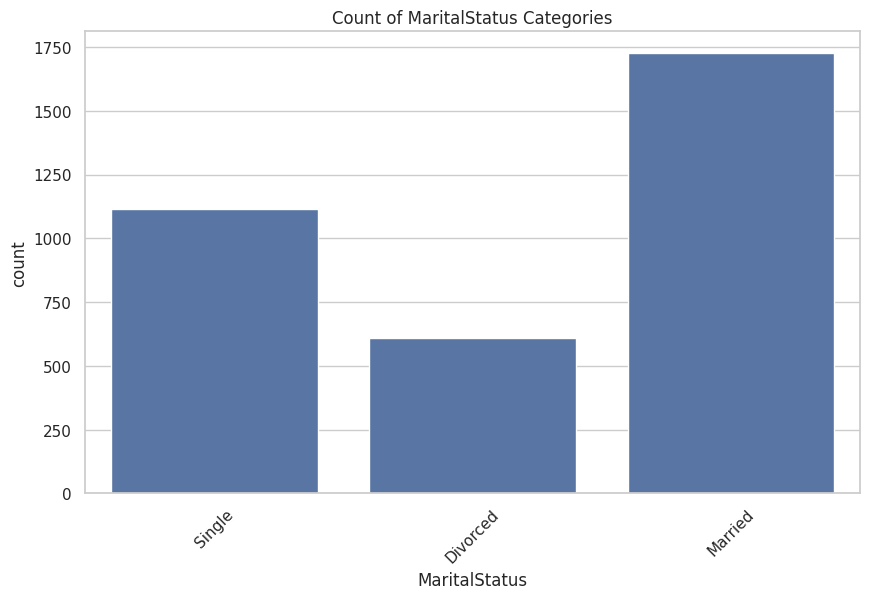

📊 Zone vs AgentBonus


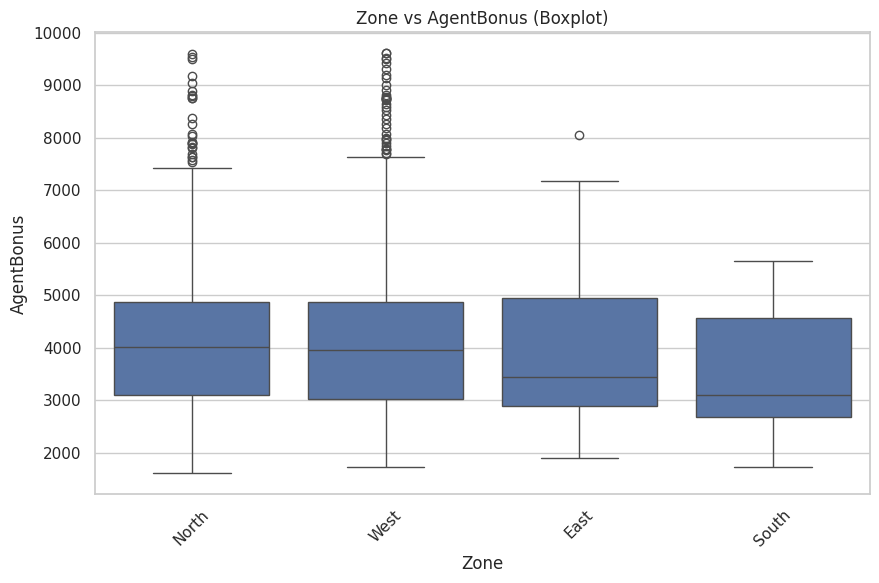

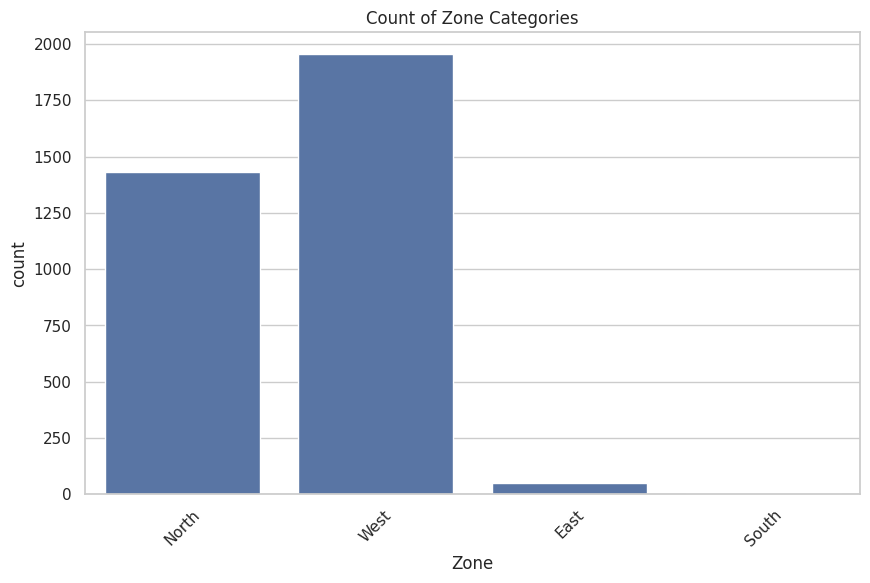

📊 PaymentMethod vs AgentBonus


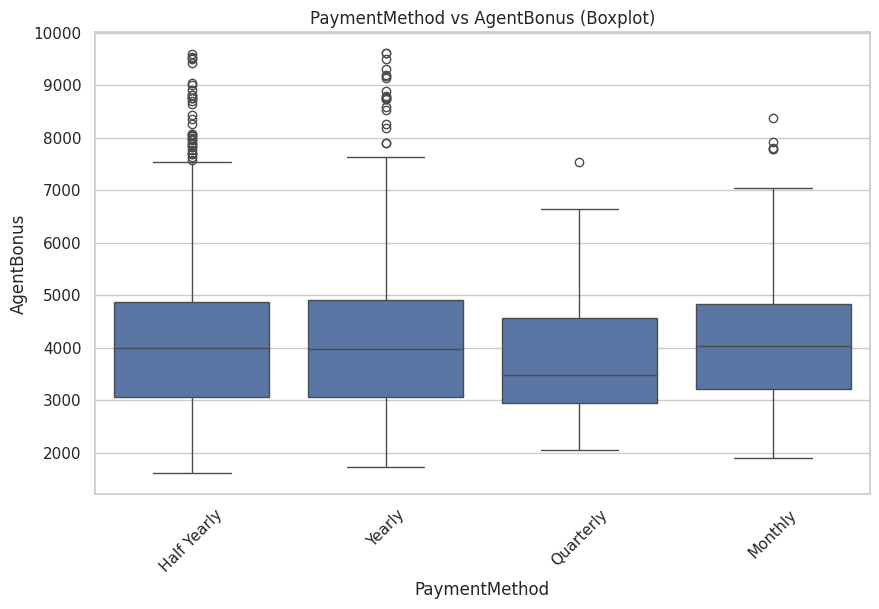

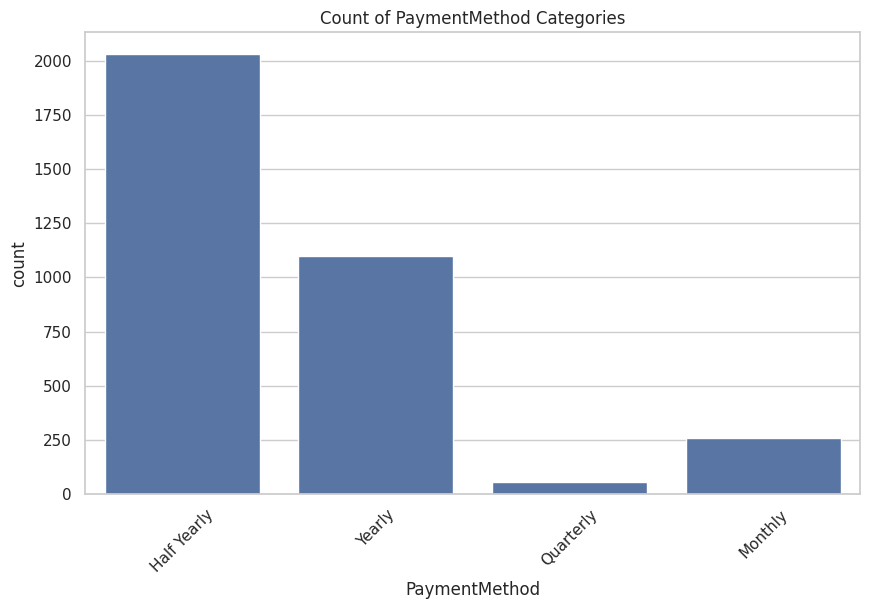

In [ ]:
categorical_cols = df.select_dtypes(include=['object']).columns

for col in categorical_cols:
    print(f'📊 {col} vs AgentBonus')

    # Boxplot
    plt.figure(figsize=(10, 6))
    sns.boxplot(x=col, y='AgentBonus', data=df)
    plt.title(f'{col} vs AgentBonus (Boxplot)')
    plt.xticks(rotation=45)
    plt.show()

    # Countplot
    plt.figure(figsize=(10, 6))
    sns.countplot(x=col, data=df)
    plt.title(f'Count of {col} Categories')
    plt.xticks(rotation=45)
    plt.show()


### Adding a Cloumn called "AgentBonusCategory"

In [69]:
df['AgentBonusCategory'] = pd.qcut(df['AgentBonus'], q=4, labels=['Low', 'Medium', 'High', 'Very High'])

In [70]:
df['AgentBonusCategory'].value_counts(normalize=True)*100

,proportion
AgentBonusCategory,
Low,25.007253
Medium,25.007253
Very High,25.007253
High,24.978242


In [71]:
pd.crosstab(df['Channel'], df['AgentBonusCategory'])  # → usable in chi2_contingency

AgentBonusCategory,Low,Medium,High,Very High
Channel,,,,
Agent,594,614,593,612
Online,95,89,100,95
Third Party Partner,173,159,168,155


In [72]:
pd.crosstab(df['Occupation'], df['AgentBonusCategory'])

AgentBonusCategory,Low,Medium,High,Very High
Occupation,,,,
Free Lancer,0,1,0,0
Large Business,77,80,79,71
Salaried,399,403,411,428
Small Business,386,378,371,363


In [73]:
pd.crosstab(df['EducationField'], df['AgentBonusCategory'])

AgentBonusCategory,Low,Medium,High,Very High
EducationField,,,,
Diploma,114,88,111,108
Engineer,77,81,78,70
Graduate,331,350,350,360
MBA,14,15,14,11
Post Graduate,56,42,48,54
Under Graduate,270,286,260,259


🧩 Mosaic Plot: Channel vs AgentBonusCategory


<Figure size 1000x600 with 0 Axes>

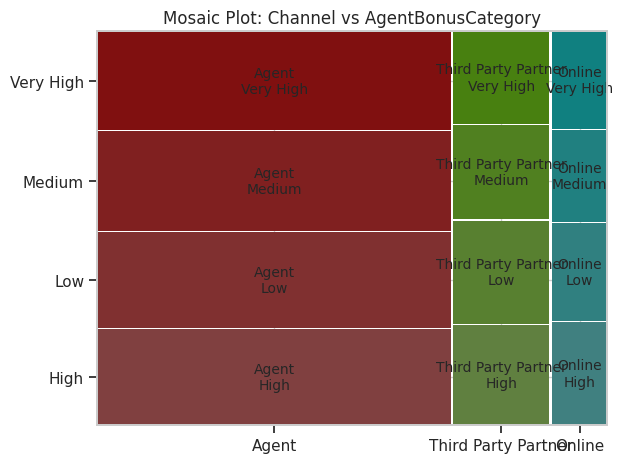

🧩 Mosaic Plot: Occupation vs AgentBonusCategory


<Figure size 1000x600 with 0 Axes>

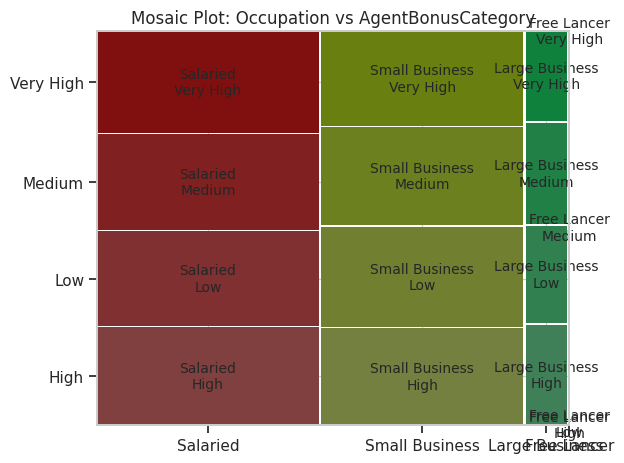

🧩 Mosaic Plot: EducationField vs AgentBonusCategory


<Figure size 1000x600 with 0 Axes>

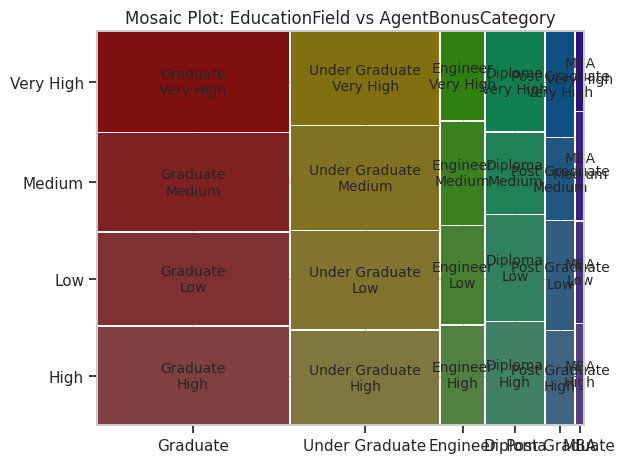

🧩 Mosaic Plot: Gender vs AgentBonusCategory


<Figure size 1000x600 with 0 Axes>

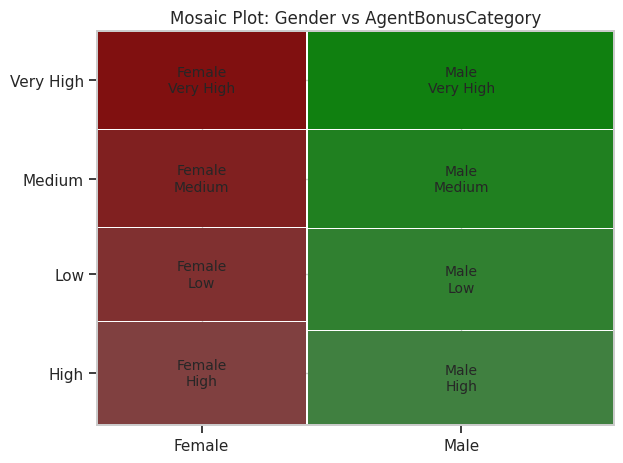

🧩 Mosaic Plot: Designation vs AgentBonusCategory


<Figure size 1000x600 with 0 Axes>

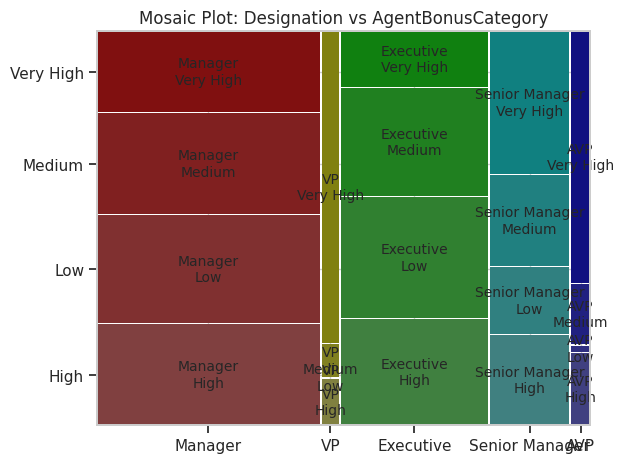

🧩 Mosaic Plot: MaritalStatus vs AgentBonusCategory


<Figure size 1000x600 with 0 Axes>

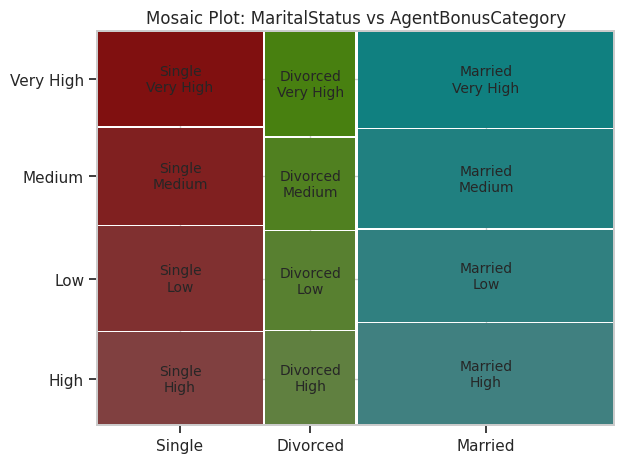

🧩 Mosaic Plot: Zone vs AgentBonusCategory


<Figure size 1000x600 with 0 Axes>

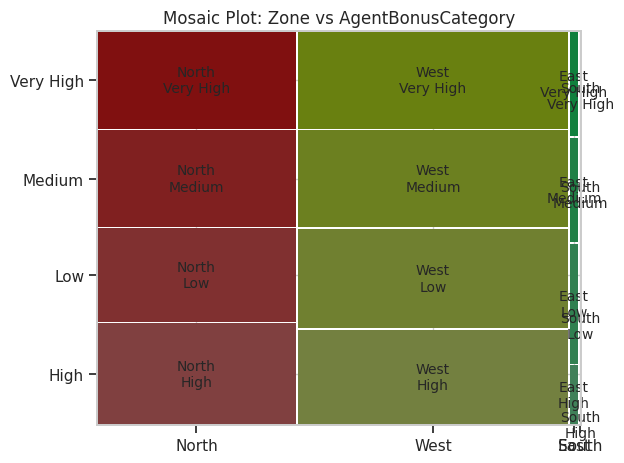

🧩 Mosaic Plot: PaymentMethod vs AgentBonusCategory


<Figure size 1000x600 with 0 Axes>

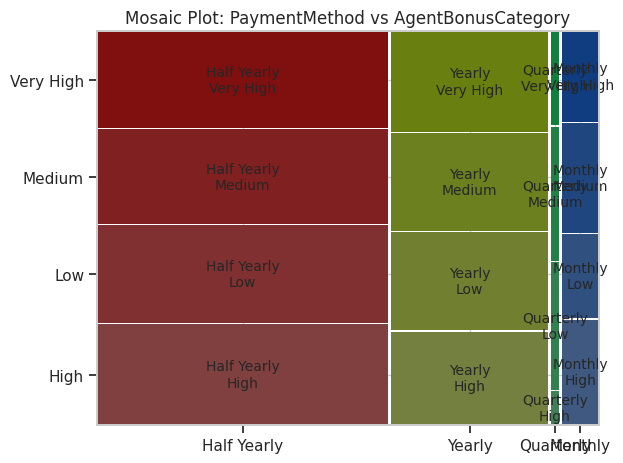

In [74]:
from statsmodels.graphics.mosaicplot import mosaic

categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
if 'AgentBonusCategory' in categorical_cols:
    categorical_cols.remove('AgentBonusCategory')

# Generate mosaic plots
for col in categorical_cols:
    print(f"🧩 Mosaic Plot: {col} vs AgentBonusCategory")

    try:
        # Drop NaNs
        mosaic_data = df[[col, 'AgentBonusCategory']].dropna()

        # Mosaic plot
        plt.figure(figsize=(10, 6))
        mosaic(mosaic_data, [col, 'AgentBonusCategory'])
        plt.title(f"Mosaic Plot: {col} vs AgentBonusCategory")
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

    except Exception as e:
        print(f"⚠️ Could not create mosaic plot for {col}: {e}")

In [75]:
import statsmodels.api as sm
from statsmodels.formula.api import logit
from statsmodels.stats.contingency_tables import Table

categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
if 'AgentBonusCategory' in categorical_cols:
    categorical_cols.remove('AgentBonusCategory')

for col in categorical_cols:
    print(f"\nChi-square test: {col} vs AgentBonusCategory")

    try:
        contingency_data = df[[col, 'AgentBonusCategory']].dropna()
        table = Table.from_data(contingency_data)
        chi2_result = table.test_nominal_association()
        p_value = chi2_result.pvalue

        print(f"   Chi-square statistic: {chi2_result.statistic:.3f}")
        print(f"   p-value: {p_value:.4f}")

        # Interpretation
        if p_value < 0.05:
            print("   Conclusion: Dependent (Statistically significant association)")
        else:
            print("   Conclusion: Independent (No significant association)")

    except Exception as e:
        print(f"   Skipped due to error: {e}")


Chi-square test: Channel vs AgentBonusCategory
   Chi-square statistic: 2.513
   p-value: 0.8670
   Conclusion: Independent (No significant association)

Chi-square test: Occupation vs AgentBonusCategory
   Chi-square statistic: 2.911
   p-value: 0.9677
   Conclusion: Independent (No significant association)

Chi-square test: EducationField vs AgentBonusCategory
   Chi-square statistic: 10.873
   p-value: 0.7616
   Conclusion: Independent (No significant association)

Chi-square test: Gender vs AgentBonusCategory
   Chi-square statistic: 3.414
   p-value: 0.3321
   Conclusion: Independent (No significant association)

Chi-square test: Designation vs AgentBonusCategory
   Chi-square statistic: 444.939
   p-value: 0.0000
   Conclusion: Dependent (Statistically significant association)

Chi-square test: MaritalStatus vs AgentBonusCategory
   Chi-square statistic: 6.916
   p-value: 0.3287
   Conclusion: Independent (No significant association)

Chi-square test: Zone vs AgentBonusCategory


In [76]:
df.head(1)

,AgentBonus,Age,CustTenure,Channel,Occupation,EducationField,Gender,ExistingProdType,Designation,NumberOfPolicy,MaritalStatus,MonthlyIncome,Complaint,ExistingPolicyTenure,SumAssured,Zone,PaymentMethod,LastMonthCalls,CustCareScore,AgentBonusCategory
0,4409,22.0,4.0,Agent,Salaried,Graduate,Female,3,Manager,2.0,Single,20993.0,1,2.0,806761.0,North,Half Yearly,5,2.0,High


## Heat Map

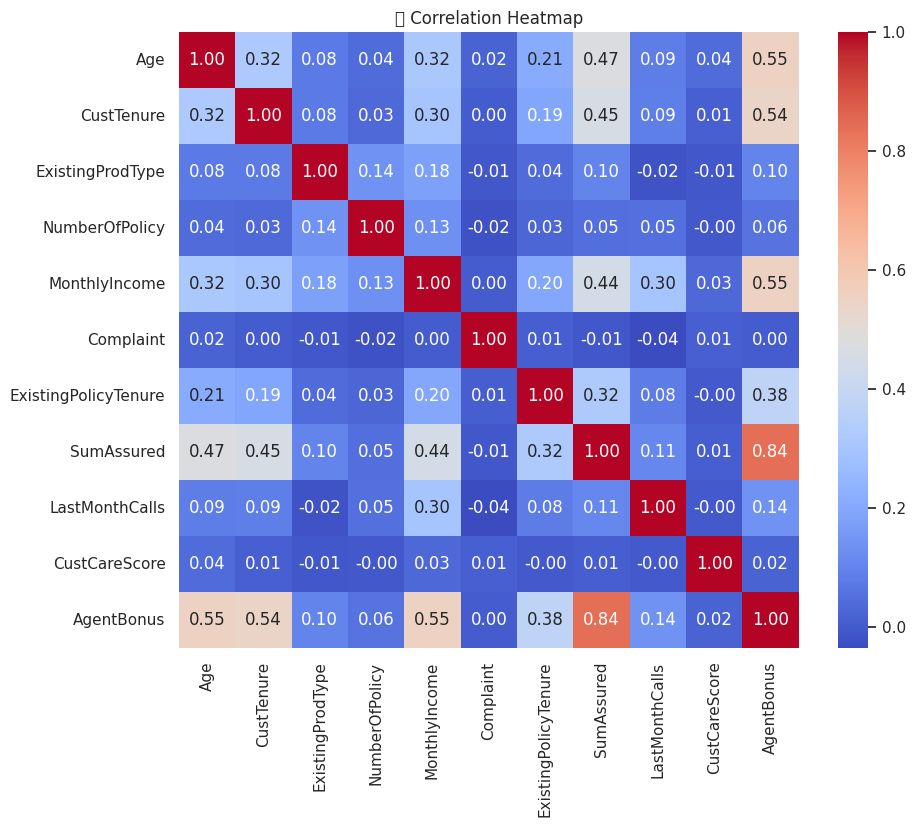

In [ ]:
plt.figure(figsize=(10, 8))
corr_matrix = df[numerical_cols.tolist() + ['AgentBonus']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("📌 Correlation Heatmap")
plt.show()


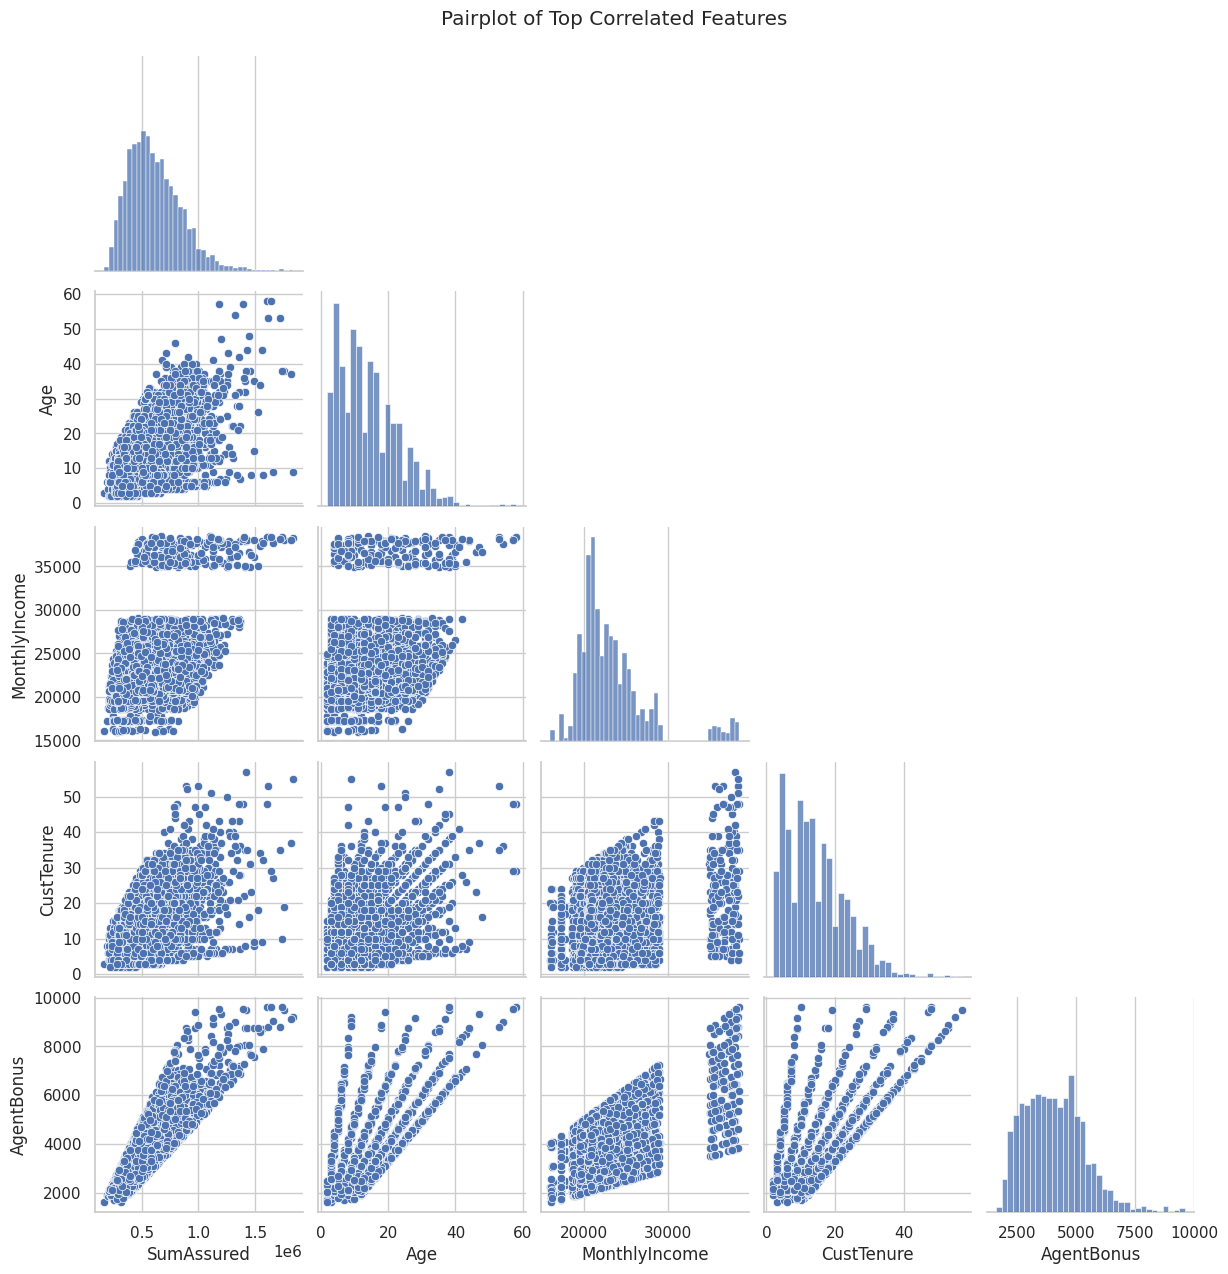

In [ ]:
strong_corrs = corr_matrix['AgentBonus'].drop('AgentBonus').abs().sort_values(ascending=False).head(4).index.tolist()

sns.pairplot(df[strong_corrs + ['AgentBonus']], corner=True)  # hides upper triangle
plt.suptitle("Pairplot of Top Correlated Features", y=1.02)
plt.show()


## Multivariate Analysis

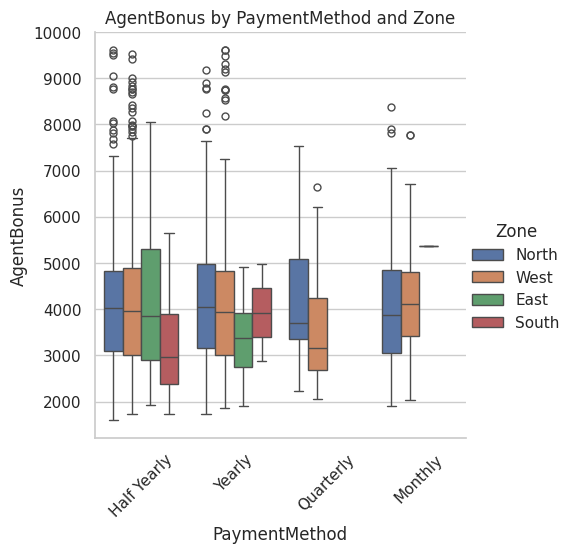

In [ ]:
sns.catplot(data=df, x="PaymentMethod", y="AgentBonus", hue="Zone", kind="box")
plt.title("AgentBonus by PaymentMethod and Zone")
plt.xticks(rotation=45)
plt.show()


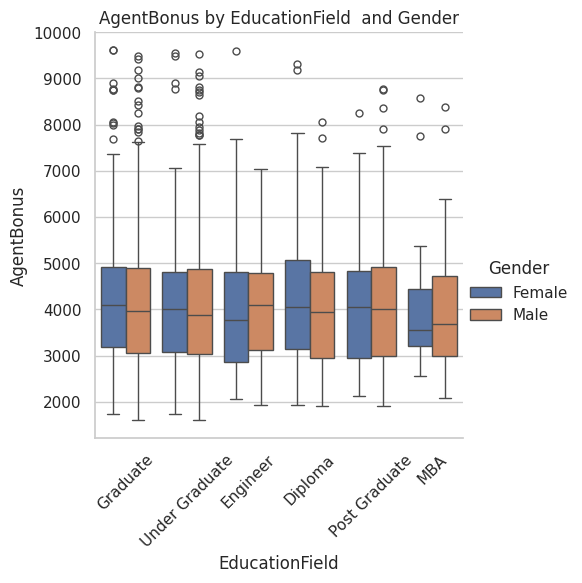

In [ ]:
sns.catplot(data=df, x="EducationField", y="AgentBonus", hue="Gender", kind="box")
plt.title("AgentBonus by EducationField  and Gender")
plt.xticks(rotation=45)
plt.show()


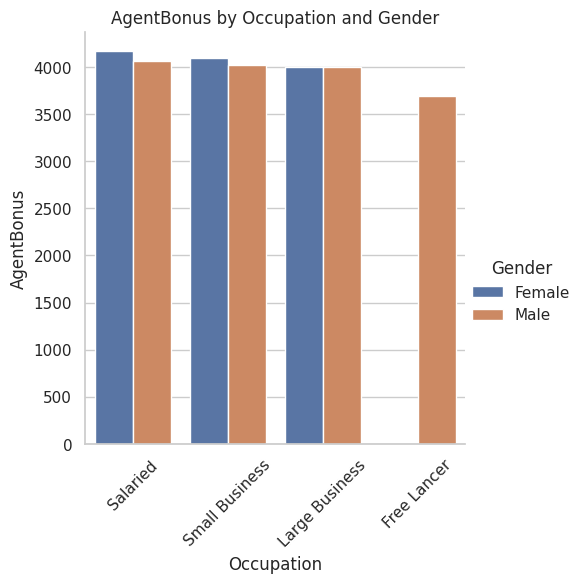

In [ ]:
sns.catplot(data=df, x="Occupation", y="AgentBonus", hue="Gender", kind="bar", ci=None)
plt.xticks(rotation=45)
plt.title("AgentBonus by Occupation and Gender")
plt.show()


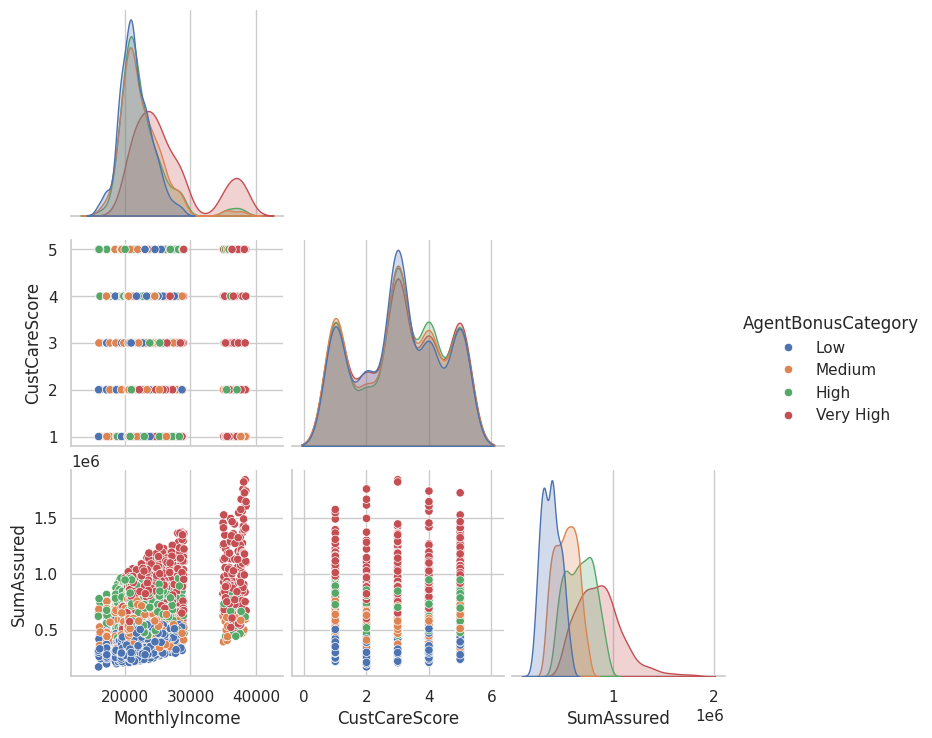

In [ ]:
sns.pairplot(df, vars=["MonthlyIncome", "CustCareScore", "SumAssured"],
             hue="AgentBonusCategory", corner=True)
plt.show()


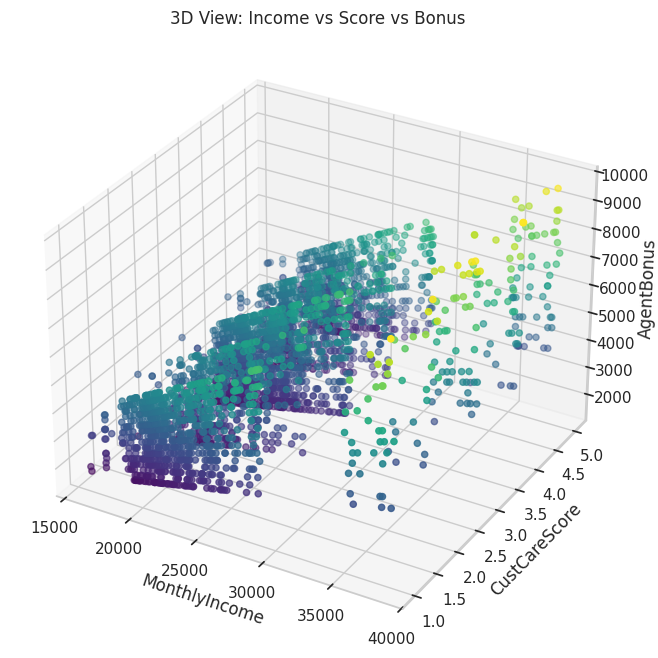

In [ ]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(df['MonthlyIncome'], df['CustCareScore'], df['AgentBonus'], c=df['AgentBonus'], cmap='viridis')
ax.set_xlabel('MonthlyIncome')
ax.set_ylabel('CustCareScore')
ax.set_zlabel('AgentBonus')
plt.title('3D View: Income vs Score vs Bonus')
plt.show()


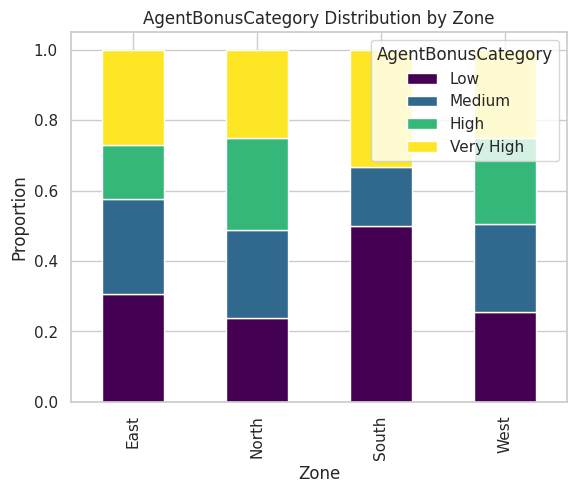

In [ ]:
ct = pd.crosstab(df['Zone'], df['AgentBonusCategory'], normalize='index')
ct.plot(kind='bar', stacked=True, colormap='viridis')
plt.title("AgentBonusCategory Distribution by Zone")
plt.ylabel("Proportion")
plt.show()


# Clustering

In [ ]:
!pip install kmodes

In [ ]:
from kmodes.kprototypes import KPrototypes

# Dynamically select columns by data type
numeric_cols = df.select_dtypes(include=['number']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
df[categorical_cols] = df[categorical_cols].astype(str)

# Combine numeric + categorical columns
X_mixed = df[numeric_cols + categorical_cols]

# Convert to NumPy array (required for K-Prototypes)
X_matrix = X_mixed.to_numpy()

# Get indices of categorical columns in X_mixed
categorical_indices = [X_mixed.columns.get_loc(col) for col in categorical_cols]

kproto = KPrototypes(n_clusters=4, init='Cao', verbose=1)
clusters = kproto.fit_predict(X_matrix, categorical=categorical_indices)

df['KPrototypes_Cluster'] = clusters

Initialization method and algorithm are deterministic. Setting n_init to 1.
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run: 1, iteration: 1/100, moves: 676, ncost: 22261748225062.277
Run: 1, iteration: 2/100, moves: 109, ncost: 22193402398752.863
Run: 1, iteration: 3/100, moves: 12, ncost: 22191529177411.56
Run: 1, iteration: 4/100, moves: 3, ncost: 22191362153954.598
Run: 1, iteration: 5/100, moves: 0, ncost: 22191362153954.598
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run: 2, iteration: 1/100, moves: 252, ncost: 24300117123377.176
Run: 2, iteration: 2/100, moves: 160, ncost: 23611470837195.023
Run: 2, iteration: 3/100, moves: 107, ncost: 23313598509849.1
Run: 2, iteration: 4/100, moves: 112, ncost: 23017090239410.88
Run: 2, iteration: 5/100, moves: 95, ncost: 22837849120054.39
Run: 2, iteration: 6/100, moves: 103, ncost: 22624072679608.08
Run: 2, iteration: 7/100, moves: 75, ncost: 22438330195673.01
Run: 2, it

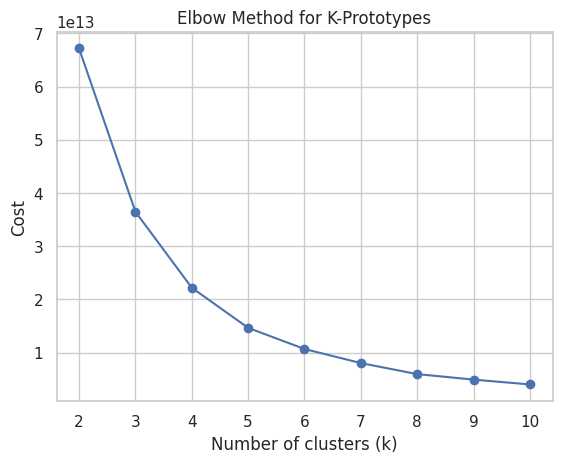

In [ ]:
from kmodes.kprototypes import KPrototypes

costs = []
K = range(2, 11)

for k in K:
    kproto = KPrototypes(n_clusters=k, init='Cao', verbose=0, random_state=42)
    clusters = kproto.fit_predict(X_matrix, categorical=categorical_indices)
    costs.append(kproto.cost_)

plt.plot(K, costs, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Cost')
plt.title('Elbow Method for K-Prototypes')
plt.show()


**After looking at the elbow plot it is clear that n=4**

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# Encode categorical variables numerically just for visualization
from sklearn.preprocessing import LabelEncoder

df_encoded = df[numeric_cols + categorical_cols].copy()
le_dict = {}
for col in categorical_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])
    le_dict[col] = le

# Standardize numeric values
scaler = StandardScaler()
df_encoded[numeric_cols] = scaler.fit_transform(df_encoded[numeric_cols])

# PCA for 2D visualization
pca = PCA(n_components=2)
components = pca.fit_transform(df_encoded)

# Plot
plt.figure(figsize=(10, 6))
sns.scatterplot(x=components[:, 0], y=components[:, 1], hue=df['KPrototypes_Cluster'], palette='Set2')
plt.title('K-Prototypes Clusters (PCA Reduced)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')
plt.show()


# Model Building

## Preparing data for modelling

In [77]:
# 1. Feature & Target split
X = df.drop(columns=['AgentBonus', 'AgentBonusCategory'])  # Drop the target and classification column
y = df['AgentBonus']

In [78]:
# 2. Identify column types
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object', 'category']).columns.tolist()

In [79]:
# 3. Preprocessing transformers
numeric_transformer = Pipeline([
    ('scaler', StandardScaler())
])

In [80]:
categorical_transformer = Pipeline([
    ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore'))
])

In [81]:
preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

In [82]:
# Separate features and target
X = df.drop(columns=['AgentBonus', 'AgentBonusCategory'])  # Drop target & derived category
y = df['AgentBonus']

# Identify categorical columns
categorical_cols = X.select_dtypes(include=['object', 'category']).columns

# One-hot encode
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)


## Splitting of the Data

In [83]:
# 4. Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [84]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Evaluation Metrics

In [85]:
# 5. Function to evaluate models
def evaluate_model(name, model, X_train, X_test, y_train, y_test, results):
    model.fit(X_train, y_train)
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    n, p = X_test.shape

    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)
    adj_r2 = 1 - (1 - test_r2) * ((n - 1)/(n - p - 1))
    rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
    mape = mean_absolute_percentage_error(y_test, y_test_pred)

    # Residual plot
    residuals = y_test - y_test_pred
    plt.figure(figsize=(6,4))
    sns.scatterplot(x=y_test_pred, y=residuals)
    plt.axhline(y=0, color='r', linestyle='--')
    plt.title(f'Residual Plot: {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Residuals')
    plt.tight_layout()
    plt.show()

    results.append({
        'Model': name,
        'Train R2': round(train_r2, 3),
        'Test R2': round(test_r2, 3),
        'Adjusted R2': round(adj_r2, 3),
        'RMSE': round(rmse, 2),
        'MAPE': round(mape * 100, 2),
        'Residual Pattern': 'No clear pattern' if abs(residuals.mean()) < 1 else 'Pattern exists'
    })


In [86]:
def get_adjusted_r2(r2, n, p):
    return 1 - ((1 - r2) * (n - 1)) / (n - p - 1)


## Parametric Models

In [87]:
# 4. Models to evaluate
models = {
    "Linear": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.01),
    "Polynomial (deg=2)": PolynomialFeatures(degree=2),
    "Polynomial (deg=3)": PolynomialFeatures(degree=3),
    "Polynomial (deg=4)": PolynomialFeatures(degree=4)
}


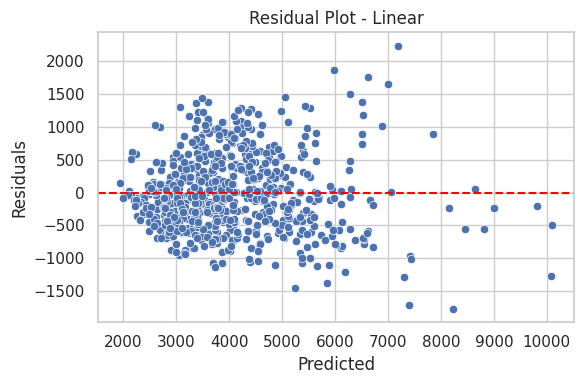

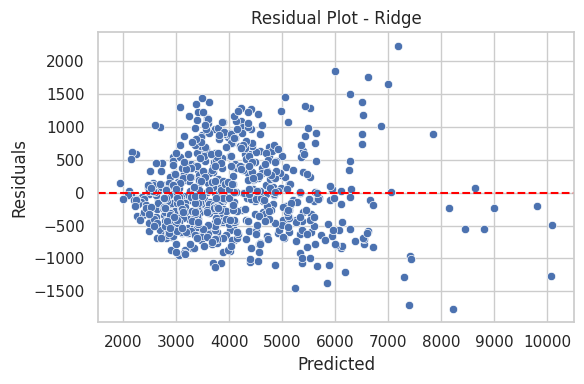

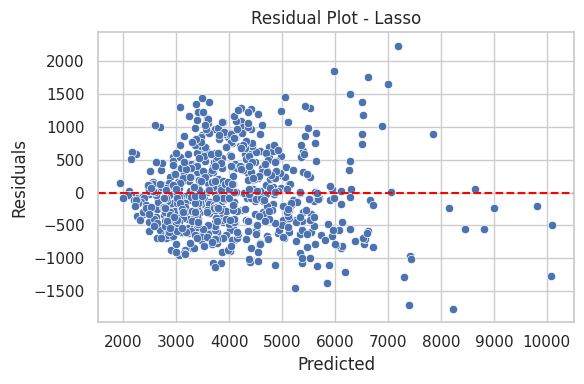

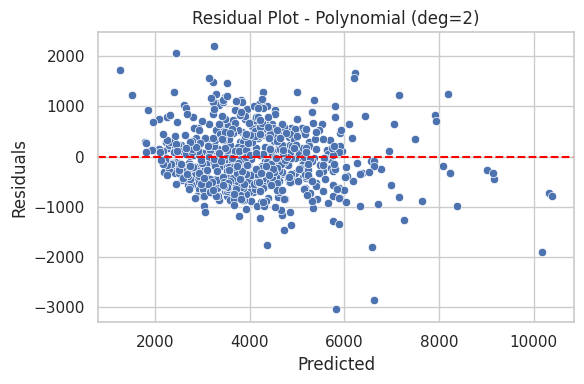

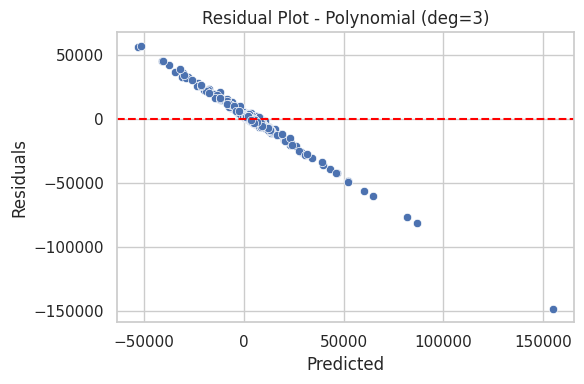

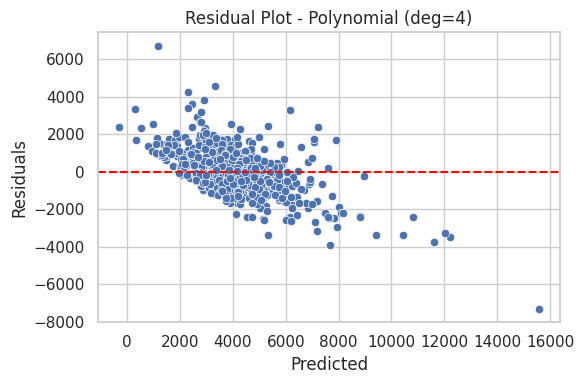

In [88]:
# 6. Results collection
results = []

for name, model in models.items():
    if name.startswith("Polynomial"):
        poly = model
        X_train_poly = poly.fit_transform(X_train_scaled)
        X_test_poly = poly.transform(X_test_scaled)
        lin = LinearRegression()
        lin.fit(X_train_poly, y_train)
        y_train_pred = lin.predict(X_train_poly)
        y_test_pred = lin.predict(X_test_poly)
        n_train, p_train = X_train_poly.shape
        n_test = X_test_poly.shape[0]
    else:
        model.fit(X_train_scaled, y_train)
        y_train_pred = model.predict(X_train_scaled)
        y_test_pred = model.predict(X_test_scaled)
        n_train, p_train = X_train_scaled.shape
        n_test = X_test_scaled.shape[0]

    # Train Metrics
    r2_train = r2_score(y_train, y_train_pred)
    adj_r2_train = get_adjusted_r2(r2_train, n_train, p_train)
    rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
    mape_train = mean_absolute_percentage_error(y_train, y_train_pred)

    # Test Metrics
    r2_test = r2_score(y_test, y_test_pred)
    adj_r2_test = get_adjusted_r2(r2_test, n_test, p_train)
    rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))
    mape_test = mean_absolute_percentage_error(y_test, y_test_pred)

    # Plot Residuals
    residuals = y_test - y_test_pred
    plt.figure(figsize=(6, 4))
    sns.scatterplot(x=y_test_pred, y=residuals)
    plt.axhline(0, color='red', linestyle='--')
    plt.title(f'Residual Plot - {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Residuals')
    plt.tight_layout()
    plt.show()

    # Append all results
    results.append({
        'Model': name,
        'R2_Train': round(r2_train, 4),
        'Adj_R2_Train': round(adj_r2_train, 4),
        'RMSE_Train': round(rmse_train, 2),
        'MAPE_Train': round(mape_train * 100, 2),
        'R2_Test': round(r2_test, 4),
        'Adj_R2_Test': round(adj_r2_test, 4),
        'RMSE_Test': round(rmse_test, 2),
        'MAPE_Test': round(mape_test * 100, 2)
    })

In [89]:
results_df = pd.DataFrame(results)
results_df

,Model,R2_Train,Adj_R2_Train,RMSE_Train,MAPE_Train,R2_Test,Adj_R2_Test,RMSE_Test,MAPE_Test
0,Linear,0.7944,0.7919,592.76,12.11,0.8103,0.8007,586.08,12.07
1,Ridge,0.7944,0.7919,592.76,12.11,0.8103,0.8008,586.02,12.07
2,Lasso,0.7944,0.7919,592.76,12.11,0.8103,0.8007,586.10,12.07
3,Polynomial (deg=2),0.8576,0.8184,493.29,10.13,0.8054,-0.4262,593.51,12.30
4,Polynomial (deg=3),0.9905,1.0060,127.54,2.18,-81.6772,9.8303,12234.27,134.08
5,Polynomial (deg=4),1.0000,1.0000,0.00,0.00,0.2188,1.0082,1189.25,22.27


In [90]:
pattern = ['Not Evident', 'Not Evident', 'Not Evident', 'Not Evident', "Pattern Exists", "Pattern Exists"]
results_df["Pattern"] = pattern
results_df

,Model,R2_Train,Adj_R2_Train,RMSE_Train,MAPE_Train,R2_Test,Adj_R2_Test,RMSE_Test,MAPE_Test,Pattern
0,Linear,0.7944,0.7919,592.76,12.11,0.8103,0.8007,586.08,12.07,Not Evident
1,Ridge,0.7944,0.7919,592.76,12.11,0.8103,0.8008,586.02,12.07,Not Evident
2,Lasso,0.7944,0.7919,592.76,12.11,0.8103,0.8007,586.10,12.07,Not Evident
3,Polynomial (deg=2),0.8576,0.8184,493.29,10.13,0.8054,-0.4262,593.51,12.30,Not Evident
4,Polynomial (deg=3),0.9905,1.0060,127.54,2.18,-81.6772,9.8303,12234.27,134.08,Pattern Exists
5,Polynomial (deg=4),1.0000,1.0000,0.00,0.00,0.2188,1.0082,1189.25,22.27,Pattern Exists


**Looking at the table, let's consider Linear Regression Model**

## Non-Parametric models

In [91]:
# Models
models = {
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "AdaBoost": AdaBoostRegressor(n_estimators=100, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, random_state=42, verbosity=0),
    "SVM": SVR()
}


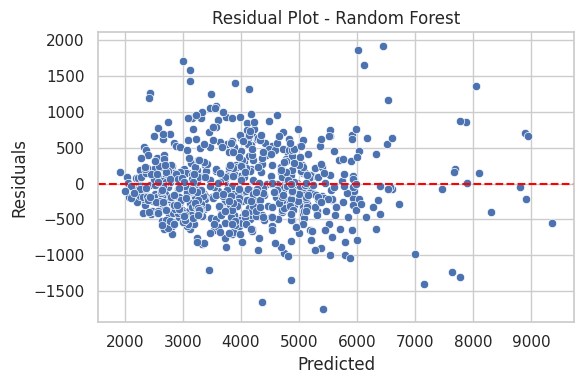

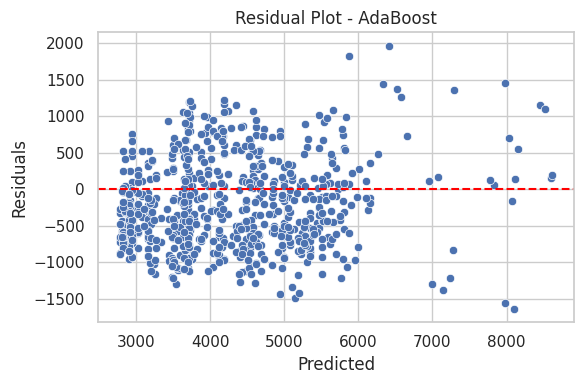

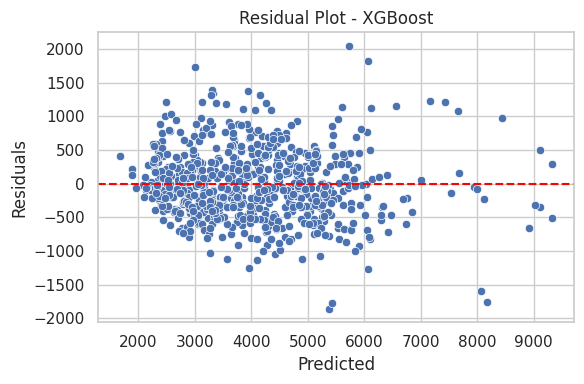

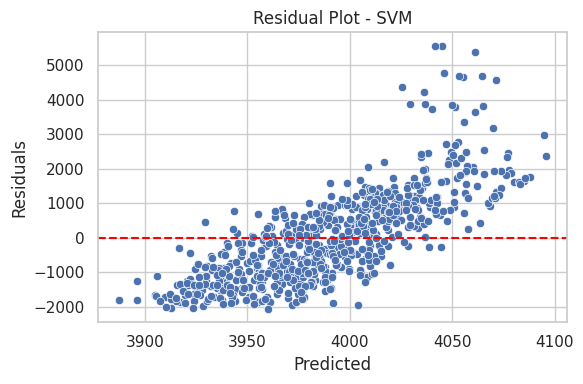

In [92]:
results_2 = []

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_train_pred = model.predict(X_train_scaled)
    y_test_pred = model.predict(X_test_scaled)

    n_train, p = X_train.shape
    n_test = X_test.shape[0]

    r2_train = r2_score(y_train, y_train_pred)
    r2_test = r2_score(y_test, y_test_pred)

    adj_r2_train = get_adjusted_r2(r2_train, n_train, p)
    adj_r2_test = get_adjusted_r2(r2_test, n_test, p)

    rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
    rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))

    mape_train = mean_absolute_percentage_error(y_train, y_train_pred) * 100
    mape_test = mean_absolute_percentage_error(y_test, y_test_pred) * 100

    # Residual Plot
    residuals = y_test - y_test_pred
    plt.figure(figsize=(6, 4))
    sns.scatterplot(x=y_test_pred, y=residuals)
    plt.axhline(0, color='red', linestyle='--')
    plt.title(f'Residual Plot - {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Residuals')
    plt.tight_layout()
    plt.show()

    results_2.append({
        'Model': name,
        'R2_Train': round(r2_train, 4),
        'Adj_R2_Train': round(adj_r2_train, 4),
        'RMSE_Train': round(rmse_train, 2),
        'MAPE_Train (%)': round(mape_train, 2),
        'R2_Test': round(r2_test, 4),
        'Adj_R2_Test': round(adj_r2_test, 4),
        'RMSE_Test': round(rmse_test, 2),
        'MAPE_Test (%)': round(mape_test, 2),
        'Residual_Pattern': 'Check plot visually'
    })



In [93]:
# Display results as DataFrame
results_df2 = pd.DataFrame(results_2)

In [94]:
results_df2

,Model,R2_Train,Adj_R2_Train,RMSE_Train,MAPE_Train (%),R2_Test,Adj_R2_Test,RMSE_Test,MAPE_Test (%),Residual_Pattern
0,Random Forest,0.9786,0.9784,191.00,3.71,0.8717,0.8653,481.89,9.67,Check plot visually
1,AdaBoost,0.7561,0.7531,645.54,15.50,0.7648,0.7529,652.58,15.59,Check plot visually
2,XGBoost,0.9901,0.9900,129.78,2.47,0.8536,0.8463,514.76,10.46,Check plot visually
3,SVM,0.0431,0.0315,1278.66,27.39,0.0451,-0.0029,1314.81,28.46,Check plot visually


In [95]:
pattern = ['Not Evident', 'Not Evident', 'Not Evident', 'Pattern Exists']
results_df2["Pattern"] = pattern
results_df2

,Model,R2_Train,Adj_R2_Train,RMSE_Train,MAPE_Train (%),R2_Test,Adj_R2_Test,RMSE_Test,MAPE_Test (%),Residual_Pattern,Pattern
0,Random Forest,0.9786,0.9784,191.00,3.71,0.8717,0.8653,481.89,9.67,Check plot visually,Not Evident
1,AdaBoost,0.7561,0.7531,645.54,15.50,0.7648,0.7529,652.58,15.59,Check plot visually,Not Evident
2,XGBoost,0.9901,0.9900,129.78,2.47,0.8536,0.8463,514.76,10.46,Check plot visually,Not Evident
3,SVM,0.0431,0.0315,1278.66,27.39,0.0451,-0.0029,1314.81,28.46,Check plot visually,Not Evident


**By looking at the residual plot and the Rsquare we can further go with Random Forest.**

# Model fine-tuning

- The model considered are Linear Regression, Polynomial Regession and Random Forest.

In [124]:
import pandas as pd
import statsmodels.api as sm
import numpy as np

# Convert all columns to float64
X_train = X_train.astype('float64')

# Add intercept term
X_const = sm.add_constant(X_train)

# Fit OLS model
ols_model = sm.OLS(y_train, X_const).fit()

# Print model summary
print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:             AgentBonus   R-squared:                       0.794
Model:                            OLS   Adj. R-squared:                  0.792
Method:                 Least Squares   F-statistic:                     328.8
Date:                Sun, 06 Jul 2025   Prob (F-statistic):               0.00
Time:                        13:59:45   Log-Likelihood:                -21515.
No. Observations:                2757   AIC:                         4.310e+04
Df Residuals:                    2724   BIC:                         4.329e+04
Df Model:                          32                                         
Covariance Type:            nonrobust                                         
                                    coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
const         

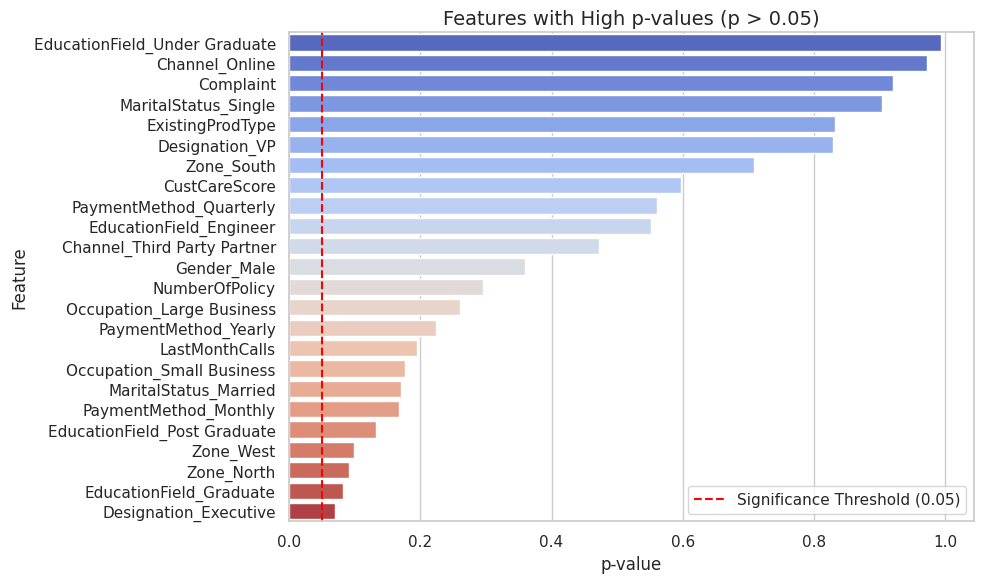

In [125]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get p-values from the fitted OLS model
p_values = ols_model.pvalues.drop('const')  # exclude intercept
high_pvals = p_values[p_values > 0.05].sort_values(ascending=False)

# Plotting
plt.figure(figsize=(10, 6))
sns.barplot(x=high_pvals.values, y=high_pvals.index, palette='coolwarm')
plt.title('Features with High p-values (p > 0.05)', fontsize=14)
plt.xlabel('p-value', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.axvline(0.05, color='red', linestyle='--', label='Significance Threshold (0.05)')
plt.legend()
plt.tight_layout()
plt.show()


In [126]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

def checking_vif(X_scaled, column_names):
    # Convert NumPy array to DataFrame
    df_scaled = pd.DataFrame(X_scaled, columns=column_names)

    # Compute VIF
    vif = pd.DataFrame()
    vif["feature"] = df_scaled.columns
    vif["VIF"] = [
        variance_inflation_factor(df_scaled.values, i)
        for i in range(df_scaled.shape[1])
    ]
    return vif

# Save column names before scaling
X_columns = X.columns

# Now run VIF check
vif_df = checking_vif(X_train_scaled, X_columns)
print(vif_df)


                          feature        VIF
0                             Age   1.316637
1                      CustTenure   1.299800
2                ExistingProdType   5.742745
3                  NumberOfPolicy   1.120776
4                   MonthlyIncome   8.364036
5                       Complaint   1.012139
6            ExistingPolicyTenure   1.129819
7                      SumAssured   1.695781
8                  LastMonthCalls   1.148206
9                   CustCareScore   1.020877
10                 Channel_Online   1.051319
11    Channel_Third Party Partner   1.040551
12      Occupation_Large Business        inf
13            Occupation_Salaried        inf
14      Occupation_Small Business        inf
15        EducationField_Engineer  19.824645
16        EducationField_Graduate  17.574157
17             EducationField_MBA   2.125622
18   EducationField_Post Graduate   4.961240
19  EducationField_Under Graduate   2.540681
20                    Gender_Male   1.032530
21        

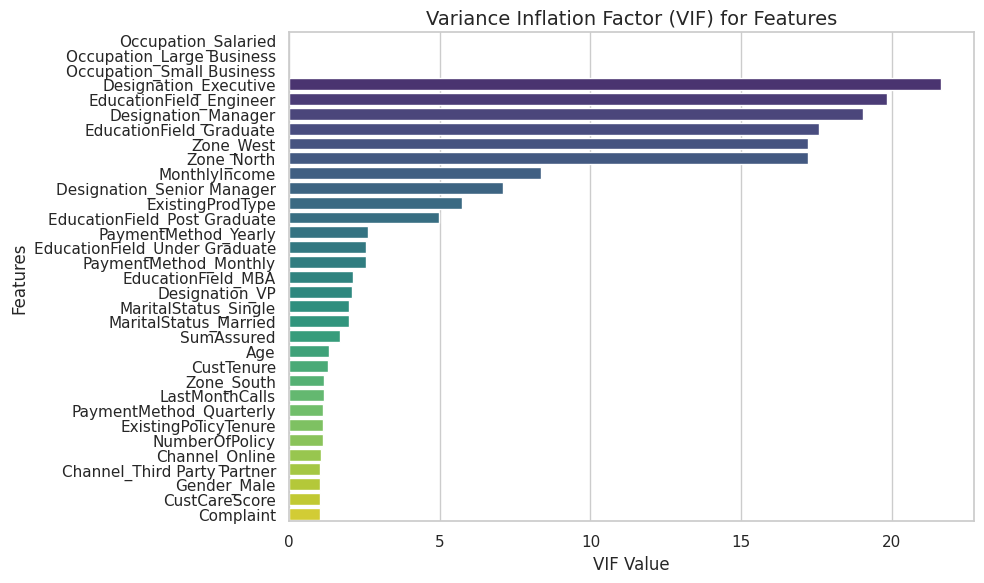

In [127]:
# Sort VIF dataframe by VIF values for better visual clarity
vif_df_sorted = vif_df.sort_values(by="VIF", ascending=False)

# Set plot size
plt.figure(figsize=(10, 6))

# Create barplot
sns.barplot(data=vif_df_sorted, x="VIF", y="feature", palette="viridis")

# Add titles and labels
plt.title("Variance Inflation Factor (VIF) for Features", fontsize=14)
plt.xlabel("VIF Value")
plt.ylabel("Features")

# Display plot
plt.tight_layout()
plt.show()


In [128]:
def calculate_vif(X):
    """
    Calculates VIF for all features in the DataFrame.
    """
    vif_data = pd.DataFrame()
    vif_data["feature"] = X.columns
    vif_data["VIF"] = [
        variance_inflation_factor(X.values, i)
        for i in range(X.shape[1])
    ]
    return vif_data

def drop_high_vif_features(X, y, threshold=5.0):
    """
    Drops high VIF features one by one and records model metrics.
    """
    X = X.copy()
    results = []

    while True:
        vif_df = calculate_vif(X)
        max_vif = vif_df["VIF"].max()
        if max_vif < threshold:
            break  # Exit loop when all VIFs are below threshold

        drop_feature = vif_df.sort_values("VIF", ascending=False).iloc[0]["feature"]

        # Fit OLS model before dropping
        X_const = sm.add_constant(X)
        model = sm.OLS(y, X_const).fit()
        adj_r2 = model.rsquared_adj
        rmse = np.sqrt(model.mse_resid)

        results.append({
            "Dropped_Feature": drop_feature,
            "Adj_R2": adj_r2,
            "RMSE": rmse,
            "Max_VIF_Before_Drop": max_vif
        })

        # Drop the feature with highest VIF
        X = X.drop(columns=[drop_feature])

    # Final model after all drops
    X_const = sm.add_constant(X)
    final_model = sm.OLS(y, X_const).fit()
    final_adj_r2 = final_model.rsquared_adj
    final_rmse = np.sqrt(final_model.mse_resid)

    results.append({
        "Dropped_Feature": "All VIFs below threshold",
        "Adj_R2": final_adj_r2,
        "RMSE": final_rmse,
        "Max_VIF_Before_Drop": calculate_vif(X)["VIF"].max()
    })

    return pd.DataFrame(results), X, final_model

# Example usage:
# Ensure X and y are numeric and X is scaled/encoded appropriately
X = X_train.astype(float)
y = y_train

vif_results_df, reduced_X, final_ols_model = drop_high_vif_features(X, y)

# Display summary
print(vif_results_df)
print(final_ols_model.summary())


             Dropped_Feature    Adj_R2        RMSE  Max_VIF_Before_Drop
0        Occupation_Salaried  0.791936  596.344349           237.711269
1              MonthlyIncome  0.791936  596.344349           118.339902
2           ExistingProdType  0.789624  599.648257            50.877562
3                  Zone_West  0.788128  601.776778            26.910692
4  Occupation_Large Business  0.787967  602.005463            21.355859
5  Occupation_Small Business  0.788031  601.913765            14.812813
6                 SumAssured  0.787889  602.116372            12.235036
7        Designation_Manager  0.547536  879.408120             7.063736
8             NumberOfPolicy  0.525856  900.230208             6.104205
9   All VIFs below threshold  0.525229  900.824829             4.921566
                            OLS Regression Results                            
Dep. Variable:             AgentBonus   R-squared:                       0.529
Model:                            OLS   Adj. R-squ

In [129]:
# Feature importance = absolute value of standardized coefficients
feature_importance = ols_model.params.abs().sort_values(ascending=False)
print("Standardized Coefficient-based Feature Importance:\n")
print(feature_importance)

Standardized Coefficient-based Feature Importance:

const                            528.350852
EducationField_MBA               276.361454
Occupation_Salaried              258.821684
Designation_Manager              249.082770
Designation_Executive            208.036082
EducationField_Graduate          168.807519
Designation_Senior Manager       168.772339
Occupation_Large Business        163.118901
EducationField_Post Graduate     162.309169
Zone_North                       161.309112
Zone_West                        156.872326
EducationField_Engineer          107.524949
Occupation_Small Business        106.410268
Zone_South                        98.078009
PaymentMethod_Monthly             97.833379
PaymentMethod_Quarterly           56.855814
PaymentMethod_Yearly              47.806225
MaritalStatus_Married             43.731426
ExistingPolicyTenure              33.398216
CustTenure                        22.137744
Age                               21.693609
Gender_Male             

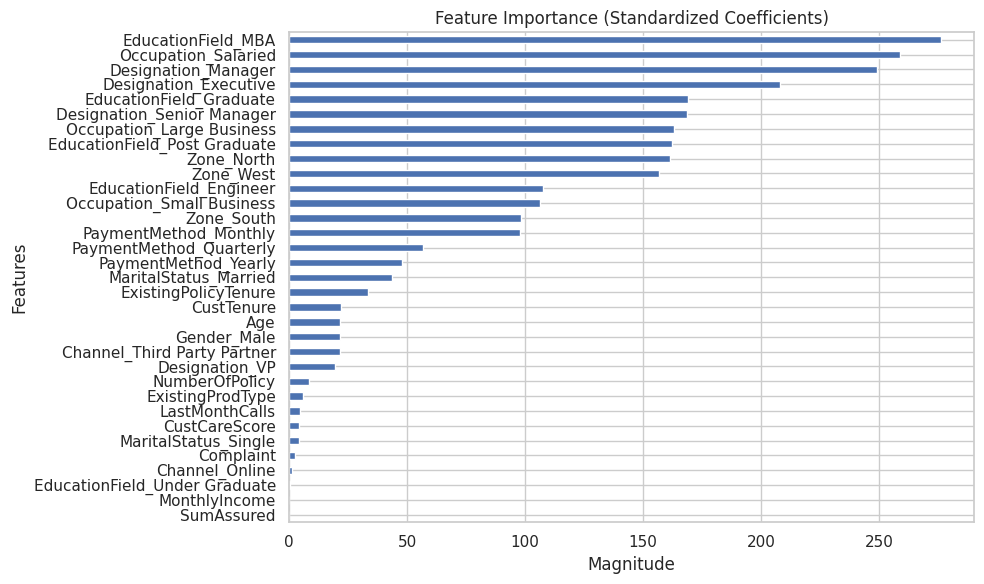

In [130]:
feature_importance[1:].plot(kind='barh', figsize=(10,6))  # Skip the constant
plt.title("Feature Importance (Standardized Coefficients)")
plt.xlabel("Magnitude")
plt.ylabel("Features")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [131]:
import pandas as pd
import statsmodels.api as sm

def backward_elimination(X, y, p_threshold=0.05):
    """
    Automatically removes features with p-values above the threshold,
    and returns a refined model and list of significant features.
    """
    X = X.copy()
    X = sm.add_constant(X)  # Add intercept

    while True:
        model = sm.OLS(y, X).fit()
        p_values = model.pvalues.drop("const")  # Exclude constant

        max_p_value = p_values.max()
        if max_p_value > p_threshold:
            feature_to_drop = p_values.idxmax()
            print(f"Dropping '{feature_to_drop}' with p-value {max_p_value:.4f}")
            X = X.drop(columns=[feature_to_drop])
        else:
            break

    final_model = sm.OLS(y, X).fit()
    return final_model, X.columns.tolist()  # model and remaining features


In [132]:
# Example usage:
final_model, significant_features = backward_elimination(X_train, y_train)

print("\nSignificant Features:")
print(significant_features)

# Check model summary
print(final_model.summary())


Dropping 'EducationField_Under Graduate' with p-value 0.9944
Dropping 'Channel_Online' with p-value 0.9720
Dropping 'Complaint' with p-value 0.9203
Dropping 'MaritalStatus_Single' with p-value 0.9050
Dropping 'Designation_VP' with p-value 0.8303
Dropping 'ExistingProdType' with p-value 0.8481
Dropping 'Zone_South' with p-value 0.7150
Dropping 'PaymentMethod_Quarterly' with p-value 0.5879
Dropping 'CustCareScore' with p-value 0.5786
Dropping 'EducationField_Engineer' with p-value 0.5379
Dropping 'Channel_Third Party Partner' with p-value 0.4706
Dropping 'Gender_Male' with p-value 0.3548
Dropping 'NumberOfPolicy' with p-value 0.3065
Dropping 'Occupation_Large Business' with p-value 0.2241
Dropping 'Occupation_Small Business' with p-value 0.2463
Dropping 'LastMonthCalls' with p-value 0.1723
Dropping 'EducationField_Post Graduate' with p-value 0.1293
Dropping 'Occupation_Salaried' with p-value 0.4749
Dropping 'EducationField_Graduate' with p-value 0.6365
Dropping 'EducationField_MBA' with 

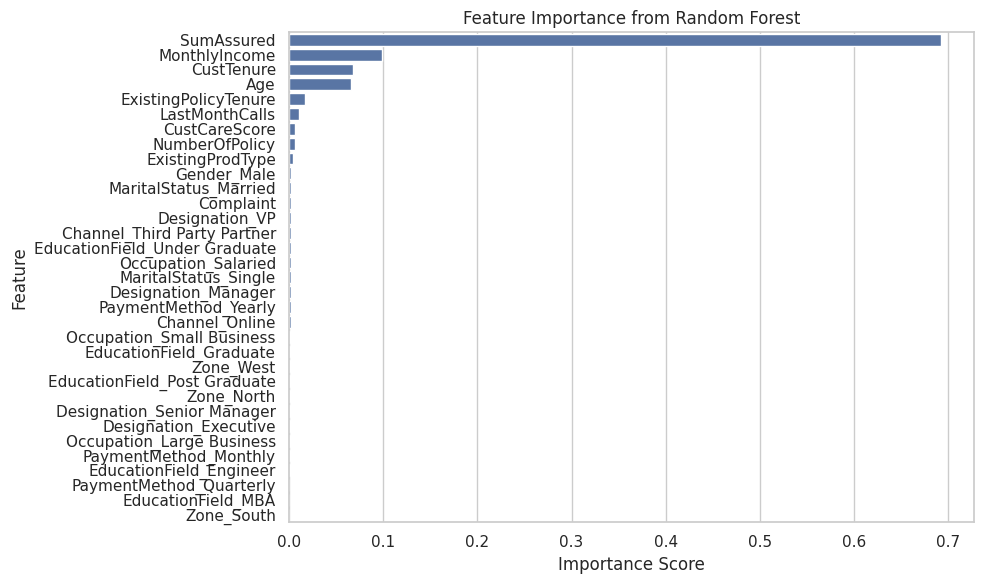

In [133]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)

importances = rf_model.feature_importances_
feat_imp = pd.Series(importances, index=X.columns).sort_values(ascending=False)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x=feat_imp, y=feat_imp.index)
plt.title('Feature Importance from Random Forest')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()


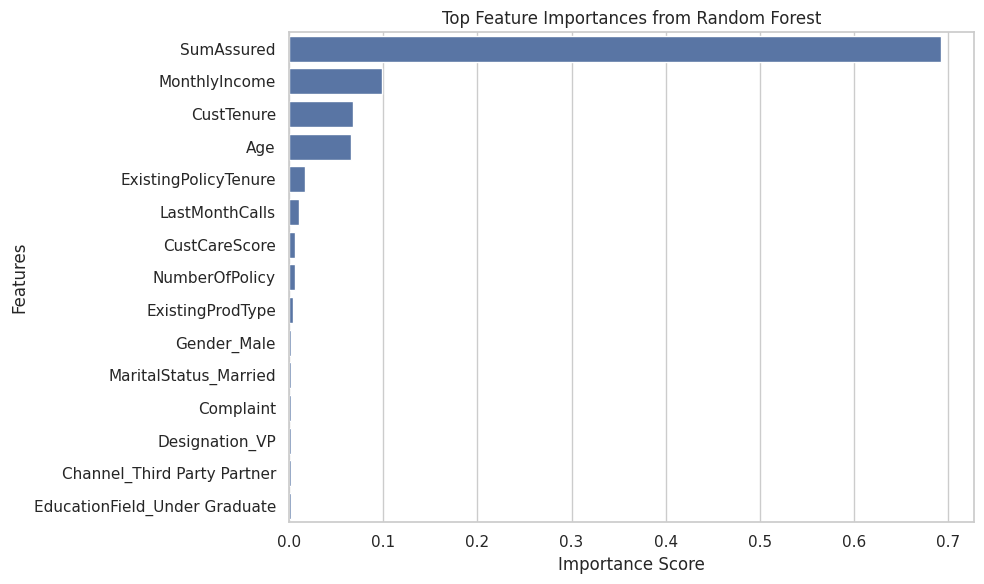

In [134]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming `rf_model` is your fitted RandomForestRegressor
importances = rf_model.feature_importances_
feature_names = X_train.columns

feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=feat_imp[:15], y=feat_imp.index[:15])  # Top 15
plt.title("Top Feature Importances from Random Forest")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.tight_layout()
plt.show()


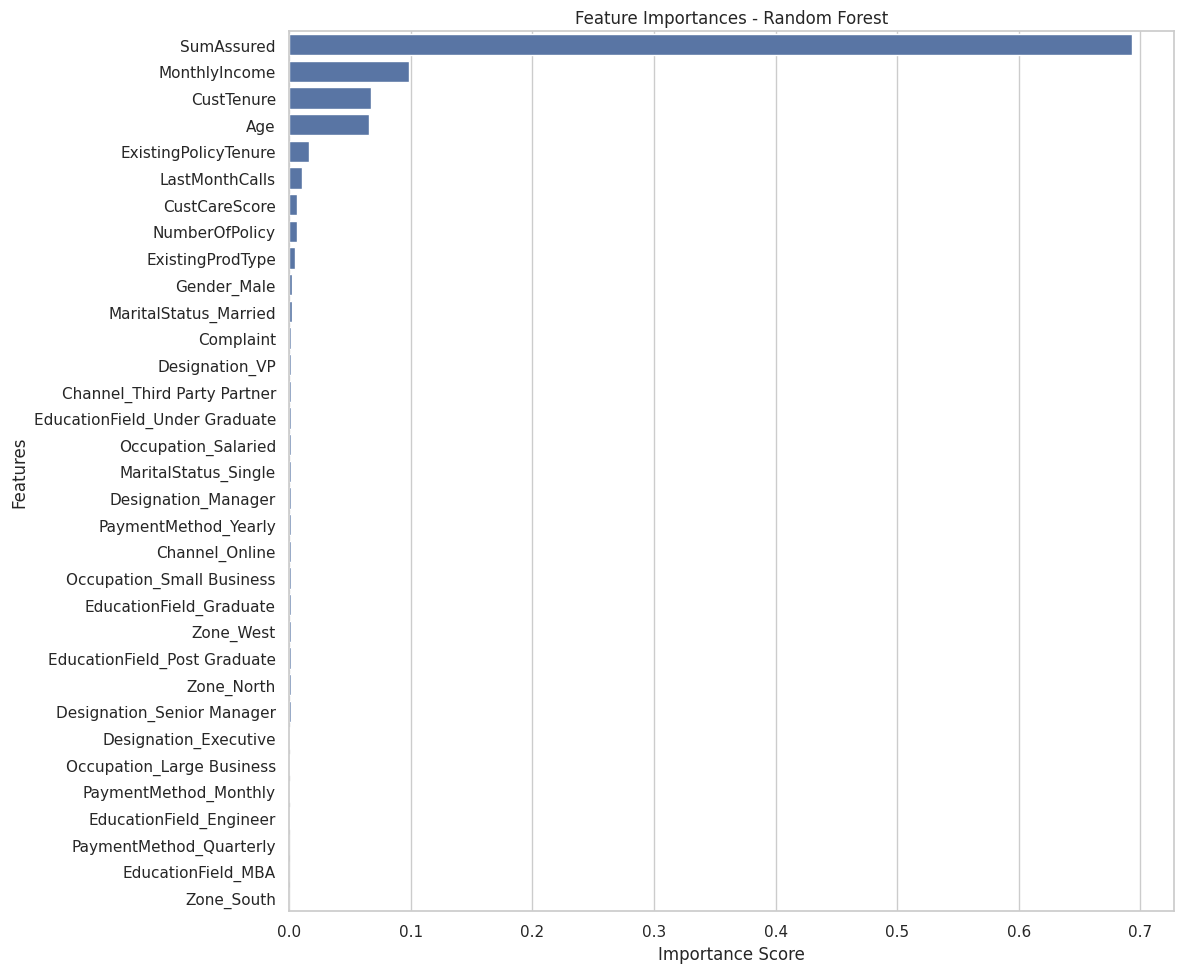

In [135]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming you have this already
importances = rf_model.feature_importances_
feature_names = X_train.columns

# Create a Series and sort
feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)

# Plot all features
plt.figure(figsize=(12, max(6, len(feat_imp) * 0.3)))  # dynamic height based on feature count
sns.barplot(x=feat_imp.values, y=feat_imp.index)
plt.title("Feature Importances - Random Forest")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.tight_layout()
plt.show()


In [136]:
# Keep top N important features
top_features = feat_imp.head(10).index.tolist()

# Retrain the model
from sklearn.ensemble import RandomForestRegressor
rf_model_refined = RandomForestRegressor(random_state=42)
rf_model_refined.fit(X_train[top_features], y_train)

# Evaluate
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_percentage_error

y_pred_rf = rf_model_refined.predict(X_test[top_features])

r2 = r2_score(y_test, y_pred_rf)
mse = mean_squared_error(y_test, y_pred_rf)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(y_test, y_pred_rf)

print(f"R²: {r2:.3f}, RMSE: {rmse:.2f}, MAPE: {mape:.2f}")


R²: 0.875, RMSE: 476.57, MAPE: 0.09


In [144]:
top_features

['SumAssured',
 'MonthlyIncome',
 'CustTenure',
 'Age',
 'ExistingPolicyTenure',
 'LastMonthCalls',
 'CustCareScore',
 'NumberOfPolicy',
 'ExistingProdType',
 'Gender_Male']

In [137]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

grid_search = GridSearchCV(RandomForestRegressor(random_state=42), param_grid, cv=3, scoring='r2')
grid_search.fit(X_train[top_features], y_train)

print("Best Params:", grid_search.best_params_)

Best Params: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}


In [138]:
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test[top_features])


In [139]:
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

# R2 score
print("Test R2 Score:", r2_score(y_test, y_pred))

# RMSE
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("Test RMSE:", rmse)


Test R2 Score: 0.8748388321906145
Test RMSE: 476.01442229639076


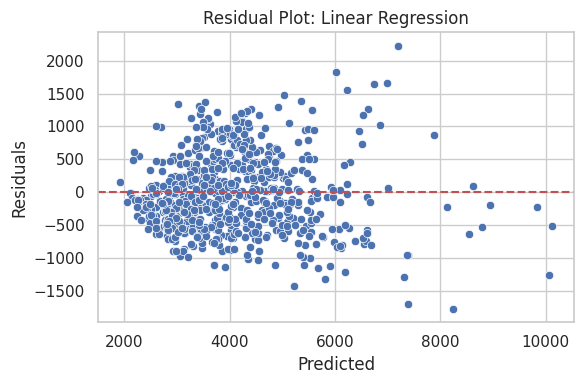

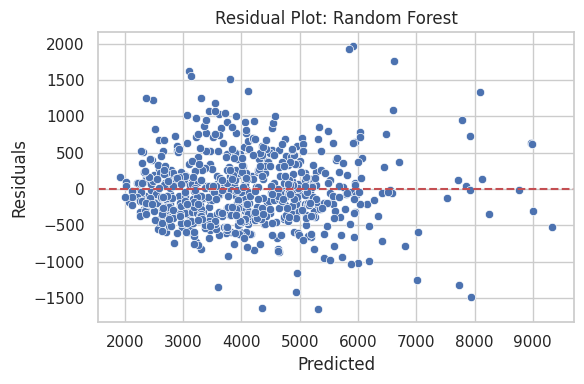


📊 Model Evaluation Summary:
                   Train R2  Test R2  Adjusted R2    RMSE   MAPE  \
Model                                                              
Linear Regression     0.793    0.814        0.811  580.26  11.92   
Random Forest         0.979    0.875        0.873  476.01   9.46   

                  Residual Pattern  
Model                               
Linear Regression   Pattern exists  
Random Forest       Pattern exists  


In [140]:
# Initialize results list
results = []

# =============================
# 1. Linear Regression (statsmodels)
# =============================

# Recreate the exact columns used in statsmodels final_model
lr_cols = final_model.model.exog_names  # includes 'const'
X_train_lr = sm.add_constant(X_train[lr_cols[1:]], has_constant='add')
X_test_lr = sm.add_constant(X_test[lr_cols[1:]], has_constant='add')

# Predict manually (since it's already fitted)
y_train_pred_lr = final_model.predict(X_train_lr)
y_test_pred_lr = final_model.predict(X_test_lr)

# Get residuals
residuals_lr = y_test - y_test_pred_lr
n_lr, p_lr = X_test_lr.shape
test_r2_lr = r2_score(y_test, y_test_pred_lr)
train_r2_lr = r2_score(y_train, y_train_pred_lr)
adj_r2_lr = get_adjusted_r2(test_r2_lr, n_lr, p_lr - 1)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_test_pred_lr))
mape_lr = mean_absolute_percentage_error(y_test, y_test_pred_lr)

# Residual plot
plt.figure(figsize=(6, 4))
sns.scatterplot(x=y_test_pred_lr, y=residuals_lr)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Residual Plot: Linear Regression')
plt.xlabel('Predicted')
plt.ylabel('Residuals')
plt.tight_layout()
plt.show()

results.append({
    'Model': 'Linear Regression',
    'Train R2': round(train_r2_lr, 3),
    'Test R2': round(test_r2_lr, 3),
    'Adjusted R2': round(adj_r2_lr, 3),
    'RMSE': round(rmse_lr, 2),
    'MAPE': round(mape_lr * 100, 2),
    'Residual Pattern': 'No clear pattern' if abs(residuals_lr.mean()) < 1 else 'Pattern exists'
})

# =============================
# 2. Random Forest (grid_search)
# =============================

# Align test data to the trained RF model
X_train_rf = X_train[grid_search.feature_names_in_]
X_test_rf = X_test[grid_search.feature_names_in_]

evaluate_model("Random Forest", grid_search, X_train_rf, X_test_rf, y_train, y_test, results)

# =============================
# Convert to DataFrame
# =============================

results_df = pd.DataFrame(results)
results_df.set_index("Model", inplace=True)

print("\n📊 Model Evaluation Summary:")
print(results_df)


In [142]:
results_df["Residual Pattern"] = "Not evident"

In [143]:
results_df

,Train R2,Test R2,Adjusted R2,RMSE,MAPE,Residual Pattern
Model,,,,,,
Linear Regression,0.793,0.814,0.811,580.26,11.92,Not evident
Random Forest,0.979,0.875,0.873,476.01,9.46,Not evident
